##### Code Copied from DiffLogicTrainer

In [1]:
import pandas as pd
import torch 
from torch import nn
from difflogic import LogicLayer, GroupSum
import numpy as np
import matplotlib.pyplot as plt
from torchviz import make_dot
import sys
from hydra import compose, initialize
from omegaconf import OmegaConf, DictConfig
import torch
import os
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset
import random
import mnist_dataset
import torchvision.transforms as transforms
from tqdm import tqdm 
import difflogic
import copy

# Fix random seeds for reproducibility
torch.manual_seed(42)             # PyTorch seed fixing
torch.cuda.manual_seed(42)        # PyTorch CUDA seed fixing (if using GPU)
np.random.seed(42)                # NumPy seed fixing
random.seed(42)                   # Python's built-in random seed fixing

# If using CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# True: If using 20x20 MNIST 
# False: If using 28x28 MNIST
small_mnist = True

# True: Binarized Images 
# False: Grayscale Images 
binarize_images = True  

# True: Mnist Dataset Digits (0-9) have same number of samples (smaller Dataset)
# False: Mnist Dataset Digits (0-9) have orignal distribution (digit 1 has more samples, etc)
evenly_partitioned = True

# Batch size
batch_size = 256
# function to binarize an image
def binarize(image, threshold=0.5):
    return (image > threshold).float()  # Threshold the image to convert to binary (0 or 1)

# define the transformation logic based on the toggle
if binarize_images:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: binarize(x))  # apply binarization if enabled
    ])
else:
    transform = transforms.Compose([
        transforms.ToTensor()  # just convert to tensor if not binarizing
    ])
train_dataset = mnist_dataset.MNIST('./data-mnist', train=True, download=True, remove_border=small_mnist, transform=transform)
test_dataset = mnist_dataset.MNIST('./data-mnist', train=False, remove_border=small_mnist, transform=transform)

# drop_last = True means it will drop the last incomplete Batch
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

# Make Dataset Evenly Partitioned
if evenly_partitioned:
    # code below is used so that all classes have the same number of samples
    train_targets = train_loader.dataset.targets
    test_targets = test_loader.dataset.targets

    train_digits_total = []
    test_digits_total = []

    for i in range(10):
        curr_tot_train = torch.sum(train_targets == i).item()
        curr_tot_test = torch.sum(test_targets == i).item()    
        train_digits_total.append(curr_tot_train)
        test_digits_total.append(curr_tot_test)

    train_digits_total, test_digits_total

    # find the minimum number of samples across all classes
    min_samples_train = min(train_digits_total)
    min_samples_test = min(test_digits_total)

    # function to trim dataset to match the minimum samples for each class and shuffle indices
    def trim_dataset(dataset, targets, min_samples):
        indices = []
        for i in range(10):
            class_indices = (targets == i).nonzero(as_tuple=True)[0]  # get indices of class i
            class_indices = class_indices[:min_samples]  # trim to min_samples
            indices.extend(class_indices)

        # shuffle indices after collecting them
        indices = torch.tensor(indices)
        indices = indices[torch.randperm(indices.size(0))]  

        return Subset(dataset, indices)

    # trim both train and test datasets to ensure all classes have the same number of samples
    trimmed_train_dataset = trim_dataset(train_loader.dataset, train_targets, min_samples_train)
    trimmed_test_dataset = trim_dataset(test_loader.dataset, test_targets, min_samples_test)

    # create DataLoaders for the trimmed datasets
    trimmed_train_loader = DataLoader(trimmed_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
    trimmed_test_loader = DataLoader(trimmed_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

    # verify the lengths of the trimmed datasets
    len(trimmed_train_loader.dataset), len(trimmed_test_loader.dataset)

    train_dataset = trimmed_train_dataset
    test_dataset = trimmed_test_dataset
    train_loader = trimmed_train_loader
    test_loader = trimmed_test_loader

dataset_size = len(train_dataset)
random_index = random.randint(0, dataset_size - 1)

if small_mnist:
    image = train_loader.dataset[random_index][0].reshape(20, 20)
else:
    image = train_loader.dataset[random_index][0].reshape(28, 28)
plt.imshow(image, cmap='gray')

class DiffLogic(nn.Module):
    def __init__(self, layers_config, output_size, tau=30):
        """
        Initializes the DiffLogic model with the specified layer configurations, output size, and temperature parameter.

        Args:
            layers_config (dict): Configuration for each logic layer, including dimensions, device, implementation, connections, and grad factor.
            output_size (int): The number of output groups.
            tau (int): Temperature parameter for the GroupSum operation.
        """
        super(DiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        for layer_name, config in layers_config.items():
            layer = LogicLayer(
                in_dim=config['in_dim'],
                out_dim=config['out_dim'],
                device=config['device'],
                implementation=config['implementation'],
                connections=config['connections'],
                grad_factor=config['grad_factor']       
            )
            layers.append(layer)
            print(layer)
        
        self.logic_layers = nn.Sequential(*layers)
        
        self.group = GroupSum(k=output_size, tau=tau)
    
    def forward(self, x):
        """
        Forward pass of the DiffLogic model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after processing through the logic layers and grouping operation.
        """
        # Move tensor to GPU
        if not isinstance(x, difflogic.PackBitsTensor):
            # Move tensor to GPU only if it's not a PackBitsTensor
            if torch.cuda.is_available():
                x = x.to('cuda')

            # Flatten the input for non-PackBitsTensor
            x = self.flatten(x)
            
        logits = self.logic_layers(x)
        group = self.group(logits)
        return group
    
class Model(nn.Module):
    def __init__(self, cfg):
        """
        Initializes the Model, loads the DiffLogic model, sets up the optimizer, loss function, and other necessary configurations.

        Args:
            cfg (dict): Configuration dictionary containing model parameters such as layer configurations, output size, tau, and learning rate.
        """
        super(Model, self).__init__()
        
        layers_config = cfg["layers_config"]
        output_size = cfg["output_size"]
        tau = cfg["tau"]
                
        self.diff_logic_model = DiffLogic(layers_config, output_size=output_size, tau=tau)
        self.optimizer = torch.optim.Adam(self.diff_logic_model.parameters(), lr=cfg["learning_rate"])
        self.log_text = ""  # Initialize the logging string
        self.data_batch = []
        self.criterion = nn.CrossEntropyLoss() # loss function for classification tasks

    def forward(self, prediction_dict):    
        """
        Forward pass to predict the model output.

        Args:
            prediction_dict (dict): Dictionary containing input data for making predictions.

        Returns:
            None: Updates the prediction_dict with the predicted output data.
        """
        input_data = prediction_dict["input_data"]
        output = self.diff_logic_model(input_data)
        self.log_text += f"State Prediction: {output}\n"
        prediction_dict["pred_output_data"] = output

    def loss(self, prediction, label):
        """
        Computes the loss between the predicted and true labels.

        Args:
            prediction (torch.Tensor): Predicted tensor output from the model.
            label (torch.Tensor): True labels tensor.

        Returns:
            torch.Tensor: The computed loss value.
        """
        return self.criterion(prediction, label)

    def step(self):
        """
        Updates the model parameters by performing a single optimization step.

        Returns:
            None
        """
        self.optimizer.step()

    def train(self, tdata, mem, batch_size):
        """
        Training method that returns the loss after receiving a batch of data.

        Args:
            tdata (any): Training data.
            mem (any): Memory buffer or additional data needed for training.
            batch_size (int): Size of the data batch for training.

        Returns:
            torch.Tensor: The loss value for the batch.
        """
        self.optimizer.zero_grad()
        loss = torch.tensor([0.0 for i in range(batch_size)])
        return loss

    def test_train(self, prediction_dict):
        """
        Training method for system development on a dummy dataset.

        Args:
            prediction_dict (dict): Dictionary containing predicted and true output data.

        Returns:
            torch.Tensor: The computed loss.
        """
        self.optimizer.zero_grad()
        loss = self.loss(prediction_dict["pred_output_data"], prediction_dict["true_output_data"]).flatten()  # Structure loss (DNN relies on down-stream prediction)  
        return loss

    def save(self, file_path, model_name='model'):
        """
        Saves the model's state dictionary to the specified file path.

        Args:
            file_path (str): Path where the model will be saved.
            model_name (str): Name of the saved model

        Returns:
            None
        """
        torch.save({
            'model_state_dict': self.diff_logic_model.state_dict(),
            'connections': [layer.indices for layer in self.diff_logic_model.logic_layers if isinstance(layer, LogicLayer)]
        }, os.path.join(file_path, f"{model_name}.pth"))
        self.log_text += f"Model saved to: {file_path}\n"

    def load(self, file_path):
        """
        Loads the model's state dictionary from the specified file path.

        Args:
            file_path (str): Path from which the model will be loaded.

        Returns:
            None
        """
        checkpoint = torch.load(file_path)
        self.diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

        # Assign connections to each LogicLayer
        for idx, layer in enumerate(self.diff_logic_model.logic_layers):
            if isinstance(layer, LogicLayer):
                layer.indices = checkpoint['connections'][idx]

        self.diff_logic_model.eval()
        self.log_text += f"Model loaded from: {file_path}\n"

    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader
        
        Args:
            data_loader: a DataLoader object, e.g. train_loader or test_loader
            
        Returns:
            float: The accuracy
        """
        correct = 0
        total = 0
    
        # Ensure model is in evaluation mode
        self.diff_logic_model.eval()

        with torch.no_grad():  # Disable gradient calculation for inference
            for batch_inputs, batch_outputs in tqdm(data_loader, desc="Running Inference"):
                batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

                # Forward pass to get predictions
                outputs = self.diff_logic_model(batch_inputs)

                # Get the predicted class (index of the maximum logit)
                _, predicted = torch.max(outputs.data, 1)

                # Count correct predictions
                total += batch_outputs.size(0)  # Total number of samples in the batch
                correct += (predicted == batch_outputs).sum().item()  # Count correct predictions

        accuracy = correct / total
        return accuracy

ModuleNotFoundError: No module named 'torchviz'

### MiniNets

##### Loading Model

In [ ]:
model_name = 'model_077'
model_name_config = model_name # from mnist_config.yaml
model_name_weights = f'binarized_{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models/trained_binary_models'
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH)
# print(model)

model.get_accuracy(test_loader)

##### Testing DiffLogic's Faster Inference Approach

In [8]:
import difflogic
import torch

def run_inference_with_packbits(model, data_loader):
    model.diff_logic_model.eval()  # Ensure model is in evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # No gradient computation needed for inference
        for batch_inputs, batch_outputs in tqdm(data_loader, desc="Running Fast Inference"):
            # Move data to GPU before converting to PackBitsTensor
            batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')
            
            # Binarize the inputs if not already done
            binarized_inputs = binarize(batch_inputs)

            # Flatten the input tensor to match expected input for PackBitsTensor
            binarized_inputs_flat = binarized_inputs.view(batch_inputs.size(0), -1)  # Flatten to [batch_size, 400]

            # Convert the boolean tensor into PackBitsTensor for efficient execution
            packed_inputs = difflogic.PackBitsTensor(binarized_inputs_flat.bool())

            # Perform inference using PackBitsTensor
            # Note: No need to move packed_inputs to GPU, it's already optimized for GPU
            outputs = model.diff_logic_model(packed_inputs)
            
            # Get predicted class (index of the maximum logit)
            _, predicted = torch.max(outputs.data, 1)
            
            # Count correct predictions
            total += batch_outputs.size(0)
            correct += (predicted == batch_outputs).sum().item()

    accuracy = correct / total
    return accuracy

run_inference_with_packbits(model, test_loader)

Running Fast Inference: 100%|██████████| 34/34 [00:01<00:00, 18.76it/s]


0.9237132352941176

##### Individual DataLoaders for each Digit

In [3]:
# gets individual dataloaders for each digit
digit_loaders = {digit: DataLoader(
    [sample for sample in train_loader.dataset if sample[1] == digit],
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    drop_last=False
) for digit in range(10)} 

# you can access loaders like this:
digit1loader = digit_loaders[1]
digit4loader = digit_loaders[4]

In [5]:
len(digit1loader.dataset)

5421

##### Plotting Experiments

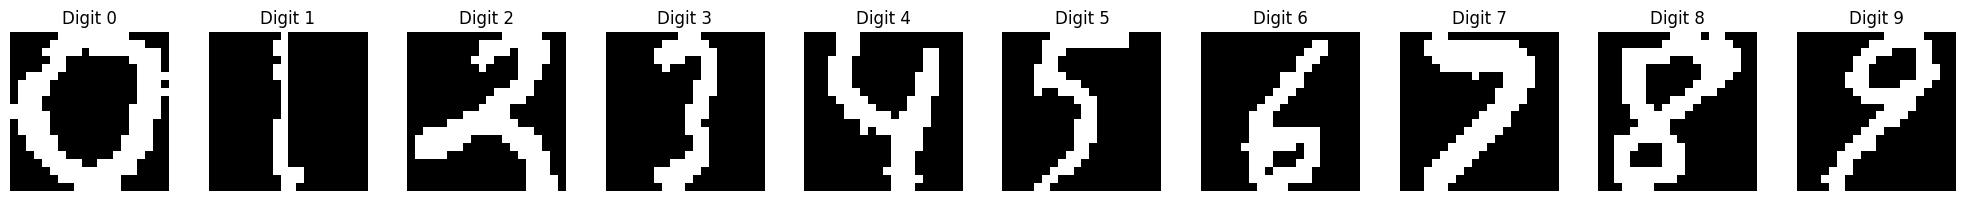

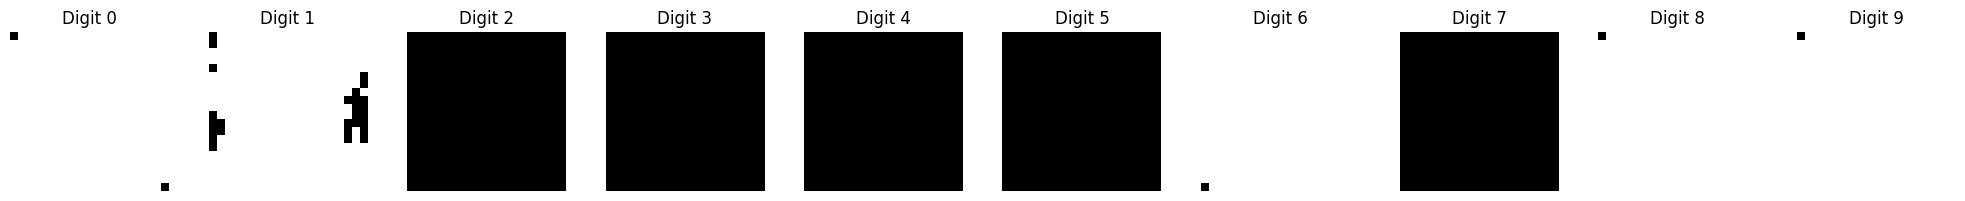

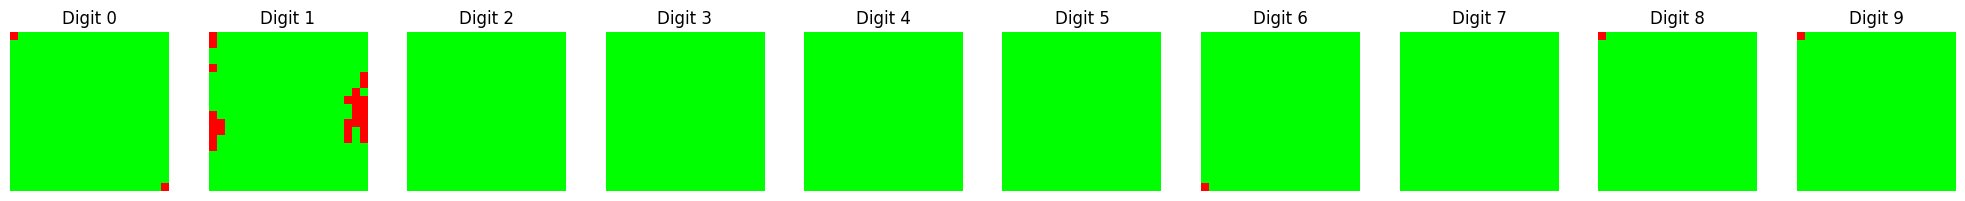

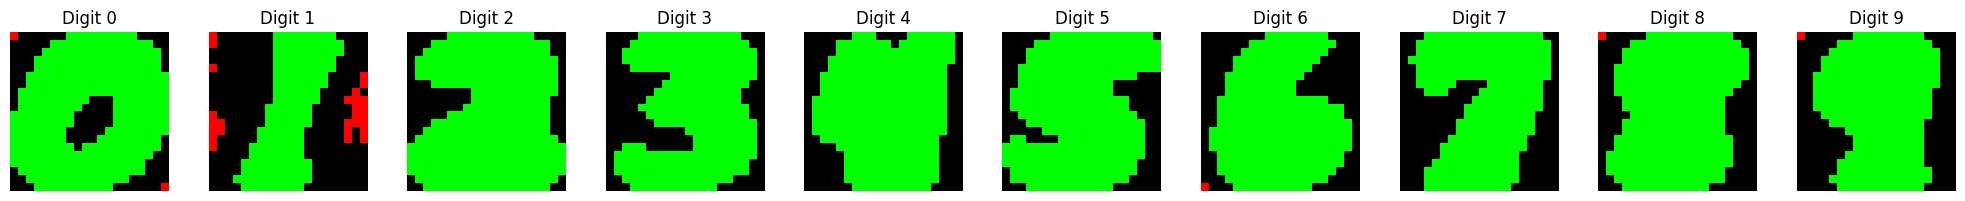

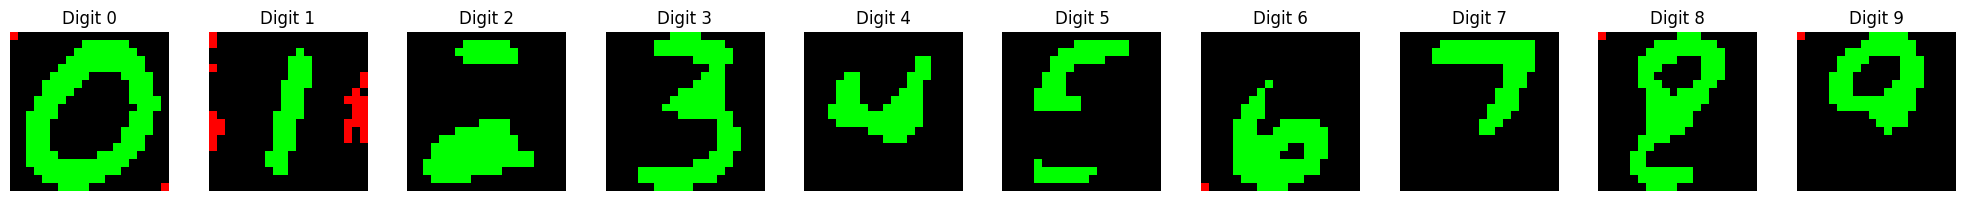

In [40]:
# displays a randomly selected sample from each digit class
fig, axes = plt.subplots(1, 10, figsize=(20, 2))  

for digit in range(10):
    digit_dataset = digit_loaders[digit].dataset  
    dataset_size = len(digit_dataset)  

    # gets a random index and retrieve the corresponding image
    random_index = random.randint(0, dataset_size - 1)
    image = digit_dataset[random_index][0].reshape(20, 20)  

    # displays image in the corresponding subplot
    axes[digit].imshow(image, cmap='gray')
    axes[digit].axis('off')  
    axes[digit].set_title(f'Digit {digit}')  

plt.tight_layout()  
plt.show()


# displays image showing every pixel that was activated at least once
fig, axes = plt.subplots(1, 10, figsize=(20, 2))  

for digit in range(10):
    combined_image = torch.zeros((20, 20), dtype=torch.int) 

    for images, _ in digit_loaders[digit]:
        images = images.squeeze(1) 
        for image in images:
            combined_image += (image > 0).int()  # adds 1 wherever a pixel is active

    # converts the combined image to binary (0 or 1)
    flattened_image = (combined_image > 0).numpy()

    # plots image for that digit
    axes[digit].imshow(flattened_image, cmap='gray')
    axes[digit].axis('off')  
    axes[digit].set_title(f'Digit {digit}')  

plt.tight_layout()  
plt.show()


# same as above but colors pixels red (was not activated) and green (was activated) across all samples for a digit
fig, axes = plt.subplots(1, 10, figsize=(20, 2))  

for digit in range(10):
    combined_image = torch.zeros((20, 20), dtype=torch.int)  

    for images, _ in digit_loaders[digit]:
        images = images.squeeze(1)  
        for image in images:
            combined_image += (image > 0).int() 
            
    # RGB image
    rgb_image = torch.zeros((20, 20, 3), dtype=torch.uint8) 
    
    # color the pixels: Red for 0, Green for 1
    rgb_image[combined_image == 0] = torch.tensor([255, 0, 0], dtype=torch.uint8) 
    rgb_image[combined_image >= 1] = torch.tensor([0, 255, 0], dtype=torch.uint8) 

    # conversion
    rgb_image_np = rgb_image.numpy()

    axes[digit].imshow(rgb_image_np)
    axes[digit].axis('off')  
    axes[digit].set_title(f'Digit {digit}') 

plt.tight_layout() 
plt.show()



# same as above but has a threshold as how many samples need to have a specific pixel for it to count
fig, axes = plt.subplots(1, 10, figsize=(20, 2))  
for digit in range(10):
    combined_image = torch.zeros((20, 20), dtype=torch.int)  

    for images, _ in digit_loaders[digit]:
        images = images.squeeze(1)  
        for image in images:
            combined_image += (image > 0).int() 
            
    # RGB image
    rgb_image = torch.zeros((20, 20, 3), dtype=torch.uint8) 
    
    # color the pixels: Red for 0, Green for 1
    rgb_image[combined_image == 0] = torch.tensor([255, 0, 0], dtype=torch.uint8) 
    rgb_image[combined_image >= 521] = torch.tensor([0, 255, 0], dtype=torch.uint8) 

    # conversion
    rgb_image_np = rgb_image.numpy()

    axes[digit].imshow(rgb_image_np)
    axes[digit].axis('off')  
    axes[digit].set_title(f'Digit {digit}') 

plt.tight_layout() 
plt.show()


# same as above but has a threshold as how many samples need to have a specific pixel for it to count
fig, axes = plt.subplots(1, 10, figsize=(20, 2))  
for digit in range(10):
    combined_image = torch.zeros((20, 20), dtype=torch.int)  

    for images, _ in digit_loaders[digit]:
        images = images.squeeze(1)  
        for image in images:
            combined_image += (image > 0).int() 
            
    # RGB image
    rgb_image = torch.zeros((20, 20, 3), dtype=torch.uint8) 
    
    # color the pixels: Red for 0, Green for 1
    rgb_image[combined_image == 0] = torch.tensor([255, 0, 0], dtype=torch.uint8) 
    rgb_image[combined_image >= 2500] = torch.tensor([0, 255, 0], dtype=torch.uint8) 

    # conversion
    rgb_image_np = rgb_image.numpy()

    axes[digit].imshow(rgb_image_np)
    axes[digit].axis('off')  
    axes[digit].set_title(f'Digit {digit}') 

plt.tight_layout() 
plt.show()

##### Hooks and Activations for Each Layer for Each Digit

In [4]:
# function to remove all forward and backward hooks in a model
def remove_all_hooks(model):
    # pass through modules (layers) in the model
    for layer in model.modules():
        # check and remove forward hooks
        if hasattr(layer, "_forward_hooks"):
            layer._forward_hooks.clear()
        
        # check and remove backward hooks
        if hasattr(layer, "_backward_hooks"):
            layer._backward_hooks.clear()
        
        # also checks for pre-forward hooks (rare) and removes them
        if hasattr(layer, "_forward_pre_hooks"):
            layer._forward_pre_hooks.clear()

# call the function to remove all hooks from the model
remove_all_hooks(model)

In [5]:
activation_counts_per_digit = {digit: [] for digit in range(10)}  

# track activations for a specific digit
def hook_fn(module, input, output, layer_idx, digit, debug=False):
    if len(activation_counts_per_digit[digit]) <= layer_idx:
        activation_counts_per_digit[digit].append(np.zeros(output.size(1), dtype=np.int64))
        
    activation_counts_per_digit[digit][layer_idx] = activation_counts_per_digit[digit][layer_idx].astype(np.int64)
    
    # prints before adding to check the behavior
    if debug:
        print(f"Before accumulation for digit {digit}, Layer {layer_idx}, Counts: {activation_counts_per_digit[digit][layer_idx]}")
        print(f"Activation counts for digit {digit} (output > 0): {(output > 0).sum(dim=0).cpu().numpy()}")
      
    activation_counts_per_digit[digit][layer_idx] += (output > 0).sum(dim=0).cpu().numpy().astype(np.int64)
    
    # prints after accumulation to see the updated counts
    if debug:
        print(f"After accumulation for digit {digit}, Layer {layer_idx}, Counts: {activation_counts_per_digit[digit][layer_idx]}")


# run forward pass and collect activations for each digit's dataset
def run_and_collect_activations(model, digit_loaders):
    
    for digit, loader in digit_loaders.items():
        hooks = []  
        
        for idx, layer in enumerate(model.diff_logic_model.logic_layers):
            if isinstance(layer, LogicLayer): 
                # register hook for the current layer and digit
                hook = layer.register_forward_hook(
                    (lambda layer_idx, digit: 
                        lambda module, input, output: 
                            hook_fn(module, input, output, layer_idx, digit))(idx, digit)
                )
                hooks.append(hook)

        # runs forward pass for each batch in the DataLoader for the current digit
        for batch_data, _ in loader:
            model.diff_logic_model(batch_data)

        # unhook all the registered hooks after the forward pass
        for hook in hooks:
            hook.remove()

# passes trained diff logic model and all digit loaders
run_and_collect_activations(model, digit_loaders)

In [6]:
activation_counts_per_digit

{0: [array([2453,  584, 1630, ..., 2490, 3541, 5389]),
  array([5088, 5023, 2264, ..., 3669, 3890, 1288])],
 1: [array([5267,  324,   12, ..., 2951,    3, 5407]),
  array([1119, 3499,    3, ..., 4034, 5288, 1423])],
 2: [array([2583, 2159, 1192, ..., 2153, 1373, 4281]),
  array([1715, 1965,  962, ..., 2954, 2716, 1517])],
 3: [array([4193, 3558, 1020, ..., 1457, 1483, 5230]),
  array([4687, 2163,  387, ..., 2793, 2278, 2616])],
 4: [array([5156, 3812,  388, ...,  621, 1465, 5274]),
  array([1420,  850,  250, ..., 4454, 4212,  923])],
 5: [array([3704, 1609, 1204, ..., 2156,  665, 5323]),
  array([3740, 2427,  192, ..., 4051, 3731, 1456])],
 6: [array([2973, 1371,   34, ..., 2207,  843, 5321]),
  array([2174, 1230,   50, ..., 3396, 4484, 1348])],
 7: [array([5277, 3101, 2034, ..., 1213, 1215, 5365]),
  array([1856, 2176,  479, ..., 4502, 1712, 3182])],
 8: [array([3513, 1931, 1327, ..., 1338,  366, 5332]),
  array([2577, 1777,  385, ..., 3478, 3056, 2742])],
 9: [array([5365, 3625, 1373

##### Thresholding LogicLayer1 and LogicLayer2

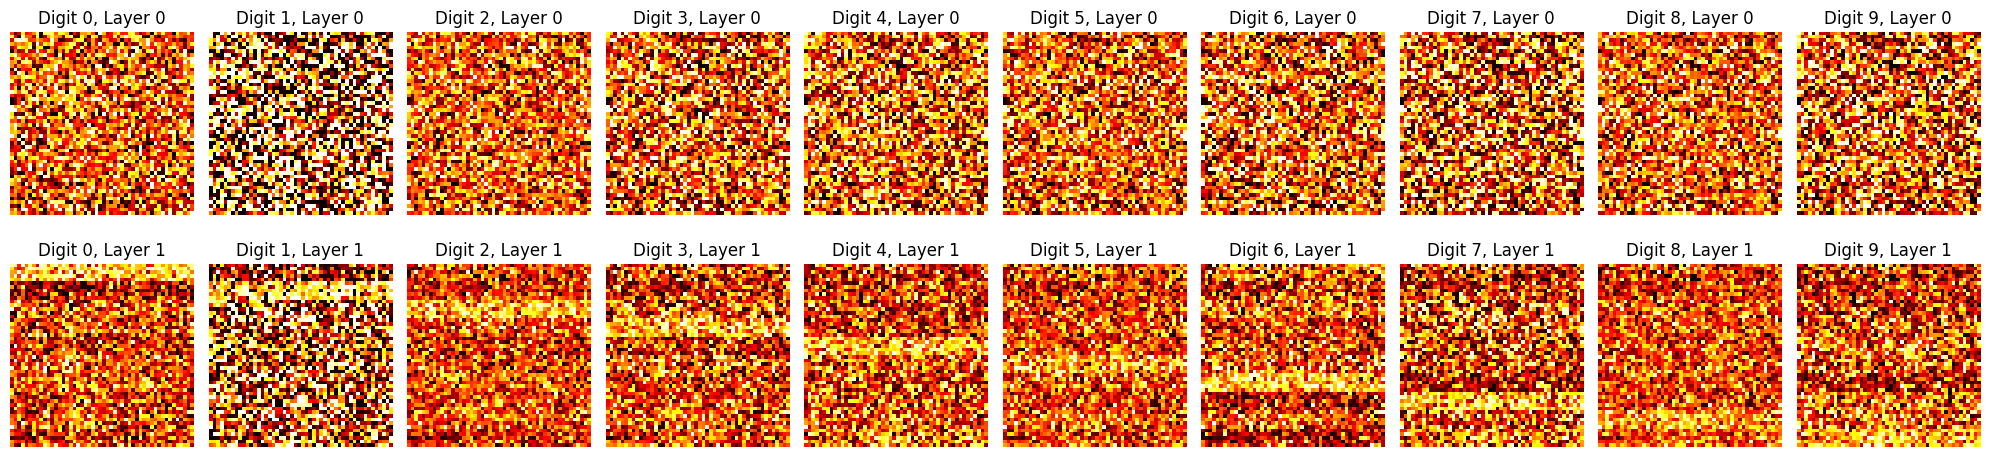

In [7]:
# empty dictionary with the same structure as activation_counts_per_digit
normalized_activation_counts_per_digit = {digit: [None, None] for digit in range(10)}

# normalize the activation counts for each digit and layer
for digit in range(10):
    for layer in range(2):
        # normalize the activation counts by dividing by the max value in the array
        normalized_activation_counts_per_digit[digit][layer] = (
            activation_counts_per_digit[digit][layer] / max(activation_counts_per_digit[digit][layer])
        )

# plotting normalized activations for all digits and both layers
fig, axs = plt.subplots(2, 10, figsize=(20, 5)) 

for digit in range(10):
    for layer in range(2):
        # reshape the normalized activations to 50x50 for visualization
        activation_image = normalized_activation_counts_per_digit[digit][layer].reshape(50, 50)
        
        axs[layer, digit].imshow(activation_image, cmap='hot', interpolation='nearest')
        axs[layer, digit].set_title(f'Digit {digit}, Layer {layer}')
        axs[layer, digit].axis('off')  
plt.tight_layout()
plt.show()

In [9]:
def threshold_activation_counts(activation_counts, threshold=2000):
    # dictionary to store the thresholded values
    thresholded_counts = {}
    
    # iterates through each digit and layer in the activation_counts
    for digit, layers in activation_counts.items():
        thresholded_counts[digit] = []
        for layer_array in layers:
            # applies threshold, set values above 'threshold' to 1, otherwise 0
            thresholded_layer = (layer_array > threshold).astype(int)
            thresholded_counts[digit].append(thresholded_layer)
    
    return thresholded_counts
thresholded_activation_counts_per_digit = threshold_activation_counts(activation_counts_per_digit)

##### Do Not Run the Cells Below

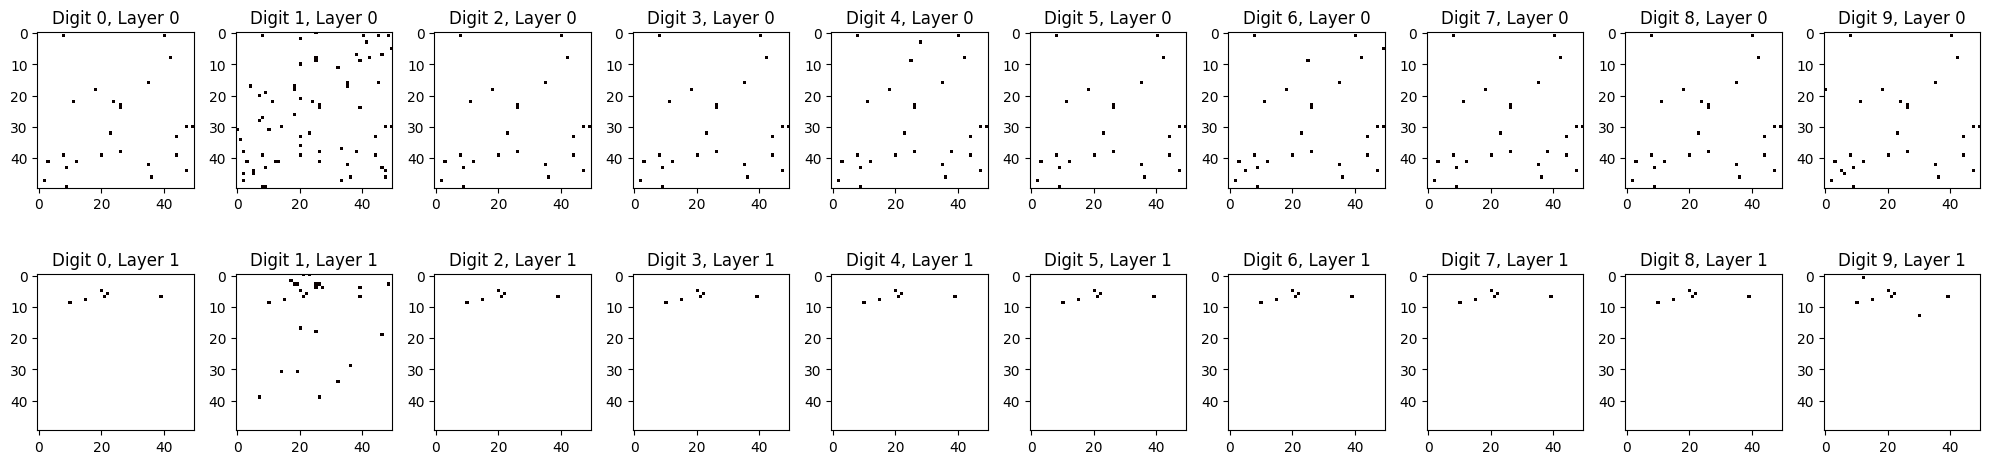

In [50]:
# threshold of 0, if a gate is activated once at any of the samples, it stays active
thresholded_activation_counts_per_digit = threshold_activation_counts(activation_counts_per_digit, threshold=0)
fig, axs = plt.subplots(2, 10, figsize=(20, 5)) 
for digit in range(10):
    for layer in range(2):
        # reshape the activations to 50x50 for visualization
        activation_image = thresholded_activation_counts_per_digit[digit][layer].reshape(50, 50)
        
        axs[layer, digit].imshow(activation_image, cmap='hot', interpolation='nearest')
        axs[layer, digit].set_title(f'Digit {digit}, Layer {layer}')
        axs[layer, digit].axis('on')  
plt.tight_layout()
plt.show()

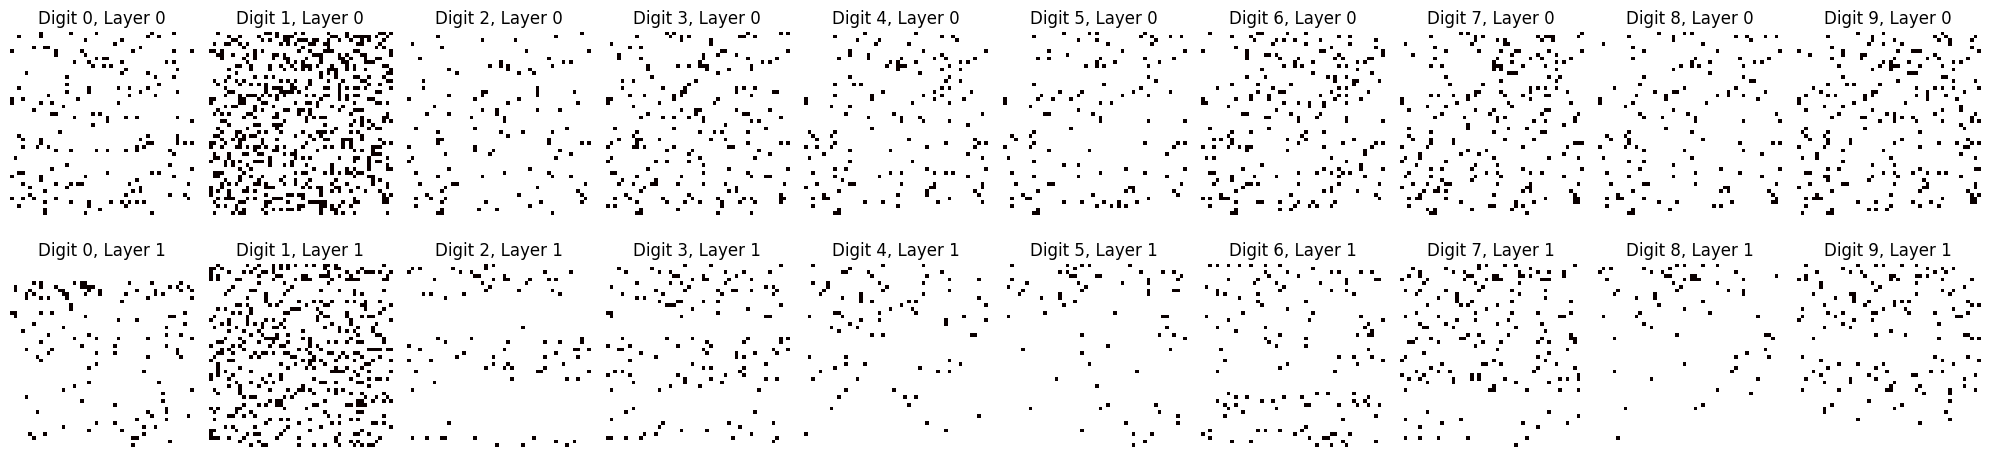

In [13]:
# threshold 250, a single gate must be activated in at least 250 different samples to appear active
thresholded_activation_counts_per_digit = threshold_activation_counts(activation_counts_per_digit, threshold=250)
fig, axs = plt.subplots(2, 10, figsize=(20, 5)) 
for digit in range(10):
    for layer in range(2):
        # reshape the activations to 50x50 for visualization
        activation_image = thresholded_activation_counts_per_digit[digit][layer].reshape(50, 50)
        
        axs[layer, digit].imshow(activation_image, cmap='hot', interpolation='nearest')
        axs[layer, digit].set_title(f'Digit {digit}, Layer {layer}')
        axs[layer, digit].axis('off')  
plt.tight_layout()
plt.show()

In [ ]:
# threshold 2000, a single gate must be activated in at least 2000 different samples to appear active
thresholded_activation_counts_per_digit = threshold_activation_counts(activation_counts_per_digit, threshold=2000)
fig, axs = plt.subplots(2, 10, figsize=(20, 5)) 
for digit in range(10):
    for layer in range(2):
        # reshape the activations to 50x50 for visualization
        activation_image = thresholded_activation_counts_per_digit[digit][layer].reshape(50, 50)
        
        axs[layer, digit].imshow(activation_image, cmap='hot', interpolation='nearest')
        axs[layer, digit].set_title(f'Digit {digit}, Layer {layer}')
        axs[layer, digit].axis('off')  
plt.tight_layout()
plt.show()

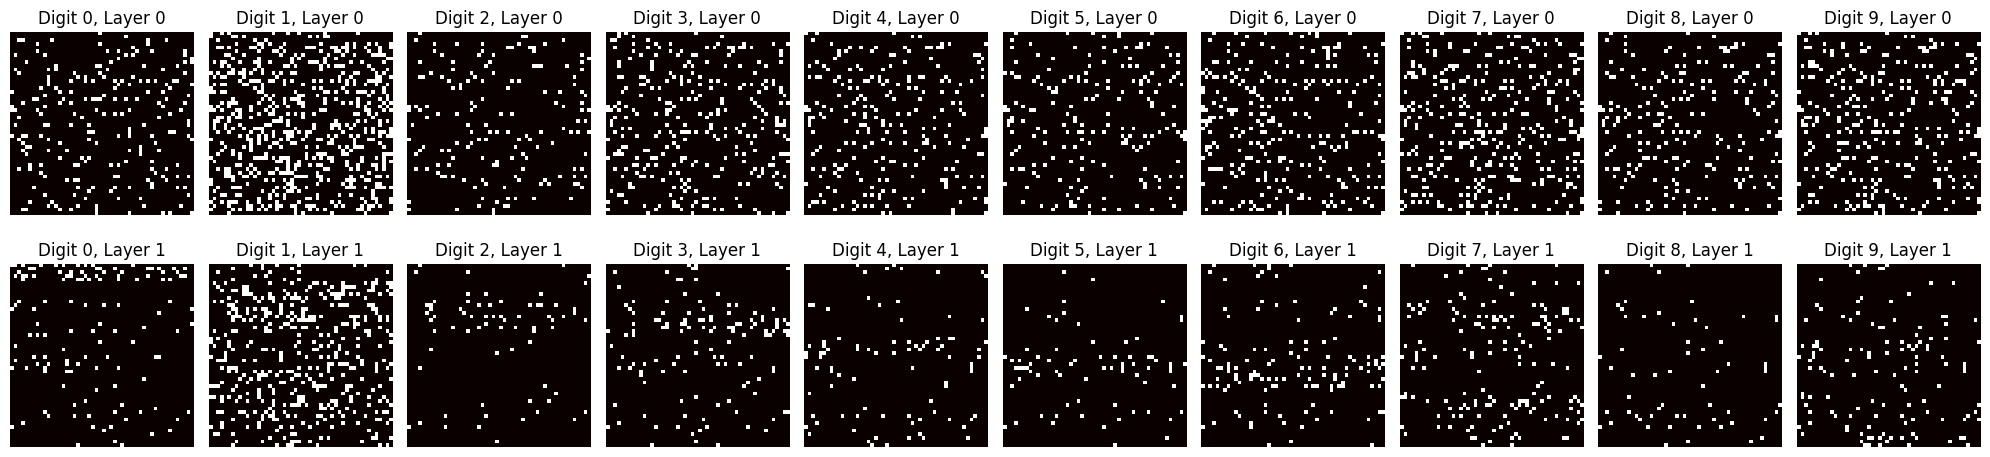

In [20]:
thresholded_activation_counts_per_digit = threshold_activation_counts(activation_counts_per_digit, threshold=5000)
fig, axs = plt.subplots(2, 10, figsize=(20, 5)) 
for digit in range(10):
    for layer in range(2):
        # reshape the activations to 50x50 for visualization
        activation_image = thresholded_activation_counts_per_digit[digit][layer].reshape(50, 50)
        
        axs[layer, digit].imshow(activation_image, cmap='hot', interpolation='nearest')
        axs[layer, digit].set_title(f'Digit {digit}, Layer {layer}')
        axs[layer, digit].axis('off')  
plt.tight_layout()
plt.show()

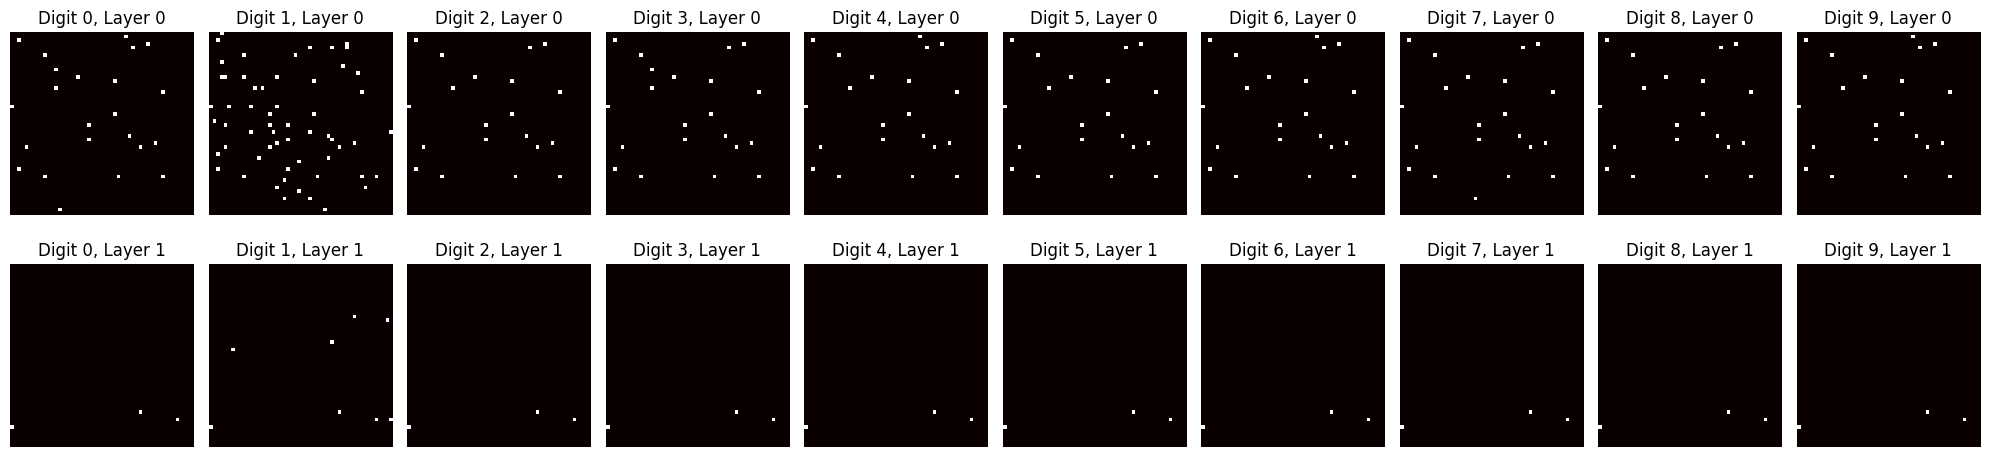

In [10]:
# need all samples to use a gate for it be displayed
thresholded_activation_counts_per_digit = threshold_activation_counts(activation_counts_per_digit, threshold=5420)
fig, axs = plt.subplots(2, 10, figsize=(20, 5)) 
for digit in range(10):
    for layer in range(2):
        # reshape the activations to 50x50 for visualization
        activation_image = thresholded_activation_counts_per_digit[digit][layer].reshape(50, 50)
        
        axs[layer, digit].imshow(activation_image, cmap='hot', interpolation='nearest')
        axs[layer, digit].set_title(f'Digit {digit}, Layer {layer}')
        axs[layer, digit].axis('off')  
plt.tight_layout()
plt.show()

In [11]:
thresholded_activation_counts_per_digit

{0: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 1: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 2: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 3: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 4: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 5: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 6: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 7: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 8: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])],
 9: [array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])]}

##### Finding and Removing Unused Nodes

In [12]:
def find_unused_nodes(thresholded_counts):
    unused_nodes_per_digit = {}

    # iterate through each digit
    for digit, layers in thresholded_counts.items():
        unused_nodes_per_digit[digit] = []
        
        # iterate through each layer for the current digit
        for layer_idx, layer_activations in enumerate(layers):
            # find the indices of nodes that are always zero in this layer
            unused_nodes = {node_idx for node_idx, activation_value in enumerate(layer_activations) if activation_value == 0}
            # append the unused nodes set for the current layer
            unused_nodes_per_digit[digit].append(unused_nodes)
            
    return unused_nodes_per_digit

unused_gates_per_digit = find_unused_nodes(thresholded_activation_counts_per_digit) # you can change the thresholding factor

##### Connections and Gates for the Overall Model

In [13]:
# gets the connections for the overall model
ALL_OPERATIONS = [
    "zero", "and", "not_implies", "a", "not_implied_by", "b", "xor", "or", 
    "not_or", "not_xor", "not_b", "implied_by", "not_a", "implies", "not_and", "one"
]

def get_all_connections(model):
    """
    Retrieves all the connections (gates and their inputs) for each layer in the network.
    
    Args:
    model (nn.Module): The network model.
    
    Returns:
    gates_per_layer (list): List of dictionaries containing the connections for each neuron in each layer.
    """
    gates_per_layer = []
    
    for layer_idx, layer in enumerate(model.diff_logic_model.logic_layers):
        layer_connections = []
        
        # for each neuron in the layer
        for neuron_idx in range(layer.weights.size(0)):
            # get the learned gate by taking the argmax of the weights for the neuron
            gate_op_idx = layer.weights[neuron_idx].argmax().item()
            learned_gate = ALL_OPERATIONS[gate_op_idx]

            # get the input connections (indices) for the gate
            input_neuron_a = layer.indices[0][neuron_idx].item()
            input_neuron_b = layer.indices[1][neuron_idx].item()

            # store the gate and connections
            layer_connections.append({
                'neuron_idx': neuron_idx,
                'gate': learned_gate,
                'inputs': (input_neuron_a, input_neuron_b),
            })
        
        gates_per_layer.append(layer_connections)
    
    return gates_per_layer

# retrieve all connections for the model
connections = get_all_connections(model)
connections

[[{'neuron_idx': 0, 'gate': 'implies', 'inputs': (303, 179)},
  {'neuron_idx': 1, 'gate': 'a', 'inputs': (193, 182)},
  {'neuron_idx': 2, 'gate': 'and', 'inputs': (66, 72)},
  {'neuron_idx': 3, 'gate': 'not_a', 'inputs': (199, 291)},
  {'neuron_idx': 4, 'gate': 'not_or', 'inputs': (361, 30)},
  {'neuron_idx': 5, 'gate': 'not_b', 'inputs': (43, 244)},
  {'neuron_idx': 6, 'gate': 'xor', 'inputs': (196, 8)},
  {'neuron_idx': 7, 'gate': 'implies', 'inputs': (173, 378)},
  {'neuron_idx': 8, 'gate': 'not_implies', 'inputs': (228, 356)},
  {'neuron_idx': 9, 'gate': 'implied_by', 'inputs': (332, 114)},
  {'neuron_idx': 10, 'gate': 'or', 'inputs': (73, 284)},
  {'neuron_idx': 11, 'gate': 'implied_by', 'inputs': (24, 207)},
  {'neuron_idx': 12, 'gate': 'not_implied_by', 'inputs': (398, 328)},
  {'neuron_idx': 13, 'gate': 'or', 'inputs': (167, 106)},
  {'neuron_idx': 14, 'gate': 'xor', 'inputs': (367, 161)},
  {'neuron_idx': 15, 'gate': 'a', 'inputs': (116, 271)},
  {'neuron_idx': 16, 'gate': 'or

##### Ensures Neurons in Deeper Layers do Not reference unexistent nodes.

In [14]:
# makes sure no gate references an unused digit
def propagate_activity(connections, unused_nodes_per_digit, digit):
    """
    Propagates neuron activity backward through the layers. If a neuron in the second layer is active, 
    it makes the connected neurons in the first layer active.
    
    Args:
    connections (list): List of connections for each layer for the overall model.
    unused_nodes_per_digit (dict): Dictionary of unused nodes per digit and layer.
    digit (int): The digit to process.

    Returns:
    updated_unused_nodes_per_digit (dict): The updated dictionary with necessary nodes marked as active.
    """
    # Copy the unused_nodes_per_digit to modify it
    updated_unused_nodes_per_digit = copy.deepcopy(unused_nodes_per_digit)

    # Iterate backward through layers (starting from the second-to-last)
    for layer_idx in range(len(connections) - 1, 0, -1):
        # Get the current layer's connections and unused nodes
        layer_connections = connections[layer_idx]
        unused_nodes_in_layer = updated_unused_nodes_per_digit[digit][layer_idx]

        # Check which neurons are active in the current layer
        active_neurons = {conn['neuron_idx'] for conn in layer_connections if conn['neuron_idx'] not in unused_nodes_in_layer}

        # Activate the neurons in the previous layer that are connected to active neurons in the current layer
        for conn in layer_connections:
            if conn['neuron_idx'] in active_neurons:
                input_a, input_b = conn['inputs']
                # Remove these neurons from the "unused" set, making them active
                updated_unused_nodes_per_digit[digit][layer_idx - 1].discard(input_a)
                updated_unused_nodes_per_digit[digit][layer_idx - 1].discard(input_b)

    return updated_unused_nodes_per_digit

def filter_connections_after_propagation(connections, unused_nodes_per_digit, digit):
    """
    Filters out unused gates and updates connections after propagating neuron activity.
    
    Args:
    - connections (list): List of connections for each layer.
    - unused_nodes_per_digit (dict): Updated dictionary of unused nodes per digit and layer.
    - digit (int): The digit to process.
    
    Returns:
    - filtered_connections (list): The adjusted connections after removing unused gates.
    """
    filtered_connections = []

    for layer_idx, layer_connections in enumerate(connections):
        layer_unused_nodes = unused_nodes_per_digit[digit][layer_idx]
        
        # Filter out connections where the neuron index is in the unused nodes
        filtered_layer_connections = [
            conn for conn in layer_connections if conn['neuron_idx'] not in layer_unused_nodes
        ]
        
        filtered_connections.append(filtered_layer_connections)

    return filtered_connections

def process_network_with_propagation(connections, unused_nodes_per_digit, digit):
    # Step 1: Propagate activity backward
    updated_unused_nodes_per_digit = propagate_activity(connections, unused_nodes_per_digit, digit)
    
    # Step 2: Filter connections based on updated activity
    filtered_connections = filter_connections_after_propagation(connections, updated_unused_nodes_per_digit, digit)
    
    return filtered_connections

# dictionary to store connections for all digits
full_connections_per_digit = {}

for digit in range(10):
    full_connections_per_digit[digit] = process_network_with_propagation(connections, unused_gates_per_digit, digit=digit)

In [15]:
for digit in range(10):
    print(len(full_connections_per_digit[digit][0]))

29
71
26
27
27
26
27
27
26
27


##### Mapping Logic Gates to Integer Indices

In [16]:
# map gate names to indices
gate_name_to_index = {name: idx for idx, name in enumerate(ALL_OPERATIONS)}
gate_name_to_index

{'zero': 0,
 'and': 1,
 'not_implies': 2,
 'a': 3,
 'not_implied_by': 4,
 'b': 5,
 'xor': 6,
 'or': 7,
 'not_or': 8,
 'not_xor': 9,
 'not_b': 10,
 'implied_by': 11,
 'not_a': 12,
 'implies': 13,
 'not_and': 14,
 'one': 15}

In [17]:
# calculation given two inputs (a and b) and their logic gate (i)
def bin_op(a, b, i):
    assert a[0].shape == b[0].shape, (a[0].shape, b[0].shape)
    if a.shape[0] > 1:
        assert a[1].shape == b[1].shape, (a[1].shape, b[1].shape)

    if i == 0:
        return torch.zeros_like(a)
    elif i == 1:
        return a * b
    elif i == 2:
        return a - a * b
    elif i == 3:
        return a
    elif i == 4:
        return b - a * b
    elif i == 5:
        return b
    elif i == 6:
        return a + b - 2 * a * b
    elif i == 7:
        return a + b - a * b
    elif i == 8:
        return 1 - (a + b - a * b)
    elif i == 9:
        return 1 - (a + b - 2 * a * b)
    elif i == 10:
        return 1 - b
    elif i == 11:
        return 1 - b + a * b
    elif i == 12:
        return 1 - a
    elif i == 13:
        return 1 - a + a * b
    elif i == 14:
        return 1 - a * b
    elif i == 15:
        return torch.ones_like(a)

In [18]:
# extract logic gates per layer
def extract_logic_gates_per_layer(adjusted_connections, gate_name_to_index):
    logic_gates_per_layer = []
    for layer_connections in adjusted_connections:
        # Convert each gate name to its corresponding index
        logic_gates = [gate_name_to_index[conn['gate']] for conn in layer_connections]
        logic_gates_per_layer.append(logic_gates)
    return logic_gates_per_layer

# loop for all digits
logic_gates_per_layer_per_digit = {}
for digit in range(10):
    adjusted_connections = full_connections_per_digit[digit]
    logic_gates_per_layer_per_digit[digit] = extract_logic_gates_per_layer(adjusted_connections, gate_name_to_index)

In [19]:
for digit in range(10):
    print(len(logic_gates_per_layer_per_digit[digit][0]))

29
71
26
27
27
26
27
27
26
27


##### Custom DiffLogic Declaration for Reduced Model Reconstruction (DO NOT RUN)

In [152]:
# modify CustomLogicLayer to use bin_op
class CustomLogicLayer(torch.nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        connections: torch.Tensor,  # manually passed connections
        logic_gates: list,          
        device: str = 'cuda',
        grad_factor: float = 1.,
        implementation: str = None,
    ):
        super().__init__()

        # use predefined logic gates and connections if provided
        self.indices = connections.to(device)
        self.logic_gates = logic_gates
        self.weights = torch.nn.parameter.Parameter(torch.randn(out_dim, 16, device=device))
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.device = device
        self.grad_factor = grad_factor
        
    def forward(self, x):
        assert x.shape[-1] == self.in_dim, (x.shape[-1], self.in_dim)
        # x: shape (batch_size, in_dim)
        # self.indices: tensor of shape (out_dim, 2)
        # Indices must be within [0, in_dim - 1]

        a = x[:, self.indices[:, 0]]  # shape (batch_size, out_dim)
        b = x[:, self.indices[:, 1]]  # shape (batch_size, out_dim)
        outputs = torch.zeros(x.shape[0], self.out_dim, device=self.device)

        for neuron_idx, gate_idx in enumerate(self.logic_gates):
            result = bin_op(a[:, neuron_idx], b[:, neuron_idx], gate_idx)
            outputs[:, neuron_idx] = result

        return outputs

    # overloading function 
    def extra_repr(self):
        return '{}, {}, {}'.format(self.in_dim, self.out_dim, 'train' if self.training else 'eval')
    
# defines custom logic network which accepts predefined connections and gates
class CustomDiffLogic(nn.Module):
    def __init__(self, layer_specs, output_size, device='cuda', tau=30):
        """
        Constructs a network using layers of logic gates and custom connections.

        Args:
        layer_specs (list): List of layer specifications, each containing
                            input size, output size, connections, and logic gates.
        device (str): Device for computation (e.g., 'cuda' or 'cpu').
        """
        super(CustomDiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        self.device = device
        
        layers = []
        # creates each layer with specific connections and logic gates
        for layer_spec in layer_specs:
            layer = CustomLogicLayer(
                in_dim=layer_spec['input_size'],
                out_dim=layer_spec['output_size'],
                device=self.device,
                connections=layer_spec['connections'],
                logic_gates=layer_spec['logic_gates'],
            )
            layers.append(layer)
    
        self.logic_layers = nn.Sequential(*layers)
        self.group = GroupSum(k=output_size, tau=tau)
        
    def forward(self, x):
        # uses cuda if available
        if torch.cuda.is_available():
            x = x.to('cuda')    
        
        x = self.flatten(x)
        logits = self.logic_layers(x)
        
        group = self.group(logits)
        return group

In [153]:
class CustomModel(nn.Module):
    def __init__(self, layer_specs, output_size=10, tau=30, lr=0.1):
        super(CustomModel, self).__init__()
        
        self.output_size = output_size
        self.tau = tau
        self.lr = lr        
            
        self.custom_diff_logic_model = CustomDiffLogic(layer_specs, output_size=self.output_size, tau=self.tau)
        params = list(self.custom_diff_logic_model.parameters())
        #print(params)
        
        self.optimizer = torch.optim.Adam(params, lr=self.lr)
        self.criterion = nn.CrossEntropyLoss()  # Loss function for classification tasks

    def forward(self, input_data):    
        """
        Forward pass to predict the model output.
        Args:
            input_data (torch.Tensor): Input tensor for prediction.
        Returns:
            torch.Tensor: Output predictions.
        """
        return self.custom_diff_logic_model(input_data)

    def loss(self, prediction, label):
        """
        Computes the loss between the predicted and true labels.
        Args:
            prediction (torch.Tensor): Predicted tensor output from the model.
            label (torch.Tensor): True labels tensor.
        Returns:
            torch.Tensor: The computed loss value.
        """
        return self.criterion(prediction, label)

    def step(self):
        """
        Updates the model parameters by performing a single optimization step.
        Returns:
            None
        """
        self.optimizer.step()

    def train_step(self, train_loader):
        """
        Single training step for a batch of data.
        Args:
            train_loader: DataLoader for training.
        Returns:
            float: The average training loss for the batch.
        """
        self.custom_diff_logic_model.train()  # Set model to training mode
        total_loss = 0
        
        for batch_inputs, batch_labels in train_loader:
            batch_inputs, batch_labels = batch_inputs.to('cuda'), batch_labels.to('cuda')
            self.optimizer.zero_grad()  # Zero gradients
            
            # Forward pass
            outputs = self.forward(batch_inputs)
            loss = self.loss(outputs, batch_labels)
            
            # Backward pass and optimization
            loss.backward()  # Compute gradients
            self.step()      # Update model weights
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        return avg_loss

    def test_train(self, train_loader):
        """
        Testing/validation on a dataset without backpropagation.
        Args:
            train_loader: DataLoader for testing/validation.
        Returns:
            float: The average loss for the test set.
        """
        self.custom_diff_logic_model.eval()  # Set model to evaluation mode
        total_loss = 0
        
        with torch.no_grad():
            for batch_inputs, batch_labels in train_loader:
                batch_inputs, batch_labels = batch_inputs.to('cuda'), batch_labels.to('cuda')
                
                # Forward pass
                outputs = self.forward(batch_inputs)
                loss = self.loss(outputs, batch_labels)
                
                total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        return avg_loss

    def save(self, file_path, model_name='model'):
        """
        Saves the model's state dictionary to the specified file path.
        Args:
            file_path (str): Path where the model will be saved.
            model_name (str): Name of the saved model
        Returns:
            None
        """
        torch.save({
            'model_state_dict': self.custom_diff_logic_model.state_dict(),
            'connections': [layer.indices for layer in self.custom_diff_logic_model.logic_layers if isinstance(layer, CustomLogicLayer)]
        }, os.path.join(file_path, f"{model_name}.pth"))

    def load(self, file_path):
        """
        Loads the model's state dictionary from the specified file path.
        Args:
            file_path (str): Path from which the model will be loaded.
        Returns:
            None
        """
        checkpoint = torch.load(file_path)
        self.custom_diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

        # Assign connections to each LogicLayer
        for idx, layer in enumerate(self.custom_diff_logic_model.logic_layers):
            if isinstance(layer, CustomLogicLayer):
                layer.indices = checkpoint['connections'][idx]

        self.custom_diff_logic_model.eval()

    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader.
        Args:
            data_loader: a DataLoader object, e.g. train_loader or test_loader.
        Returns:
            float: The accuracy.
        """
        correct = 0
        total = 0
    
        self.custom_diff_logic_model.eval()  # Set model to evaluation mode

        with torch.no_grad():  # Disable gradient calculation for inference
            for batch_inputs, batch_labels in tqdm(data_loader, desc="Running Inference"):
                batch_inputs, batch_labels = batch_inputs.to('cuda'), batch_labels.to('cuda')

                # Forward pass to get predictions
                outputs = self.custom_diff_logic_model(batch_inputs)

                # Get the predicted class (index of the maximum logit)
                _, predicted = torch.max(outputs.data, 1)

                # Count correct predictions
                total += batch_labels.size(0)  # Total number of samples in the batch
                correct += (predicted == batch_labels).sum().item()  # Count correct predictions

        accuracy = correct / total
        return accuracy

##### CustomDiffLogic and Model but with CUDA

In [20]:
import difflogic_cuda
from difflogic.packbitstensor import PackBitsTensor

class LogicLayerCudaFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, a, b, w, given_x_indices_of_y_start, given_x_indices_of_y):
        ctx.save_for_backward(x, a, b, w, given_x_indices_of_y_start, given_x_indices_of_y)
        return difflogic_cuda.forward(x, a, b, w)

    @staticmethod
    def backward(ctx, grad_y):
        x, a, b, w, given_x_indices_of_y_start, given_x_indices_of_y = ctx.saved_tensors
        grad_y = grad_y.contiguous()

        grad_w = grad_x = None
        if ctx.needs_input_grad[0]:
            grad_x = difflogic_cuda.backward_x(x, a, b, w, grad_y, given_x_indices_of_y_start, given_x_indices_of_y)
        if ctx.needs_input_grad[3]:
            grad_w = difflogic_cuda.backward_w(x, a, b, grad_y)
        return grad_x, None, None, grad_w, None, None, None

# modify CustomLogicLayer to use bin_op
class CustomLogicLayer(torch.nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        connections: torch.Tensor,  # manually passed connections
        logic_gates: list,          
        device: str = 'cuda',
        grad_factor: float = 1.,
        implementation: str = None,
    ):
        super().__init__()

        # use predefined logic gates and connections if provided
        connections = tuple([torch.tensor(t).to(device) for t in connections.T.cpu().detach().numpy()])
        print(connections)
        self.indices = connections
        self.logic_gates = logic_gates
        #self.weights = torch.nn.parameter.Parameter(torch.randn(out_dim, 16, device=device))
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.device = device
        self.grad_factor = grad_factor
        
        self.implementation = implementation
        if self.implementation is None and device == 'cuda':
            self.implementation = 'cuda'
        elif self.implementation is None and device == 'cpu':
            self.implementation = 'python'
        assert self.implementation in ['cuda', 'python'], self.implementation
        
        if self.implementation == 'cuda':
            """
            Defining additional indices for improving the efficiency of the backward of the CUDA implementation.
            """
            given_x_indices_of_y = [[] for _ in range(in_dim)]
            indices_0_np = self.indices[0].cpu().numpy()
            indices_1_np = self.indices[1].cpu().numpy()
            for y in range(out_dim):
                given_x_indices_of_y[indices_0_np[y]].append(y)
                given_x_indices_of_y[indices_1_np[y]].append(y)
            self.given_x_indices_of_y_start = torch.tensor(
                np.array([0] + [len(g) for g in given_x_indices_of_y]).cumsum(), device=device, dtype=torch.int64)
            self.given_x_indices_of_y = torch.tensor(
                [item for sublist in given_x_indices_of_y for item in sublist], dtype=torch.int64, device=device)
        
    def forward(self, x):
        if isinstance(x, PackBitsTensor):
            assert not self.training, 'PackBitsTensor is not supported for the differentiable training mode.'
            assert self.device == 'cuda', 'PackBitsTensor is only supported for CUDA, not for {}. ' \
                                          'If you want fast inference on CPU, please use CompiledDiffLogicModel.' \
                                          ''.format(self.device)
        else:
            if self.grad_factor != 1.:
                x = GradFactor.apply(x, self.grad_factor)

        if self.implementation == 'cuda':
            if isinstance(x, PackBitsTensor):
                return self.forward_cuda_eval(x)
            return self.forward_cuda(x)
        elif self.implementation == 'python':
            return self.forward_python(x)
        else:
            raise ValueError(self.implementation)
            
    def forward_python(self, x):
        assert x.shape[-1] == self.in_dim, (x[0].shape[-1], self.in_dim)

        if self.indices[0].dtype == torch.int64 or self.indices[1].dtype == torch.int64:
            print(self.indices[0].dtype, self.indices[1].dtype)
            self.indices = self.indices[0].long(), self.indices[1].long()
            print(self.indices[0].dtype, self.indices[1].dtype)

        a, b = x[..., self.indices[0]], x[..., self.indices[1]]
        if self.training:
            x = bin_op_s(a, b, torch.nn.functional.softmax(self.weights, dim=-1))
        else:
            weights = torch.nn.functional.one_hot(self.weights.argmax(-1), 16).to(torch.float32)
            x = bin_op_s(a, b, weights)
        return x
    
    def forward_cuda(self, x):
        if self.training:
            assert x.device.type == 'cuda', x.device
        assert x.ndim == 2, x.ndim

        x = x.transpose(0, 1)
        x = x.contiguous()

        assert x.shape[0] == self.in_dim, (x.shape, self.in_dim)

        a, b = self.indices

        if self.training:
            w = torch.nn.functional.softmax(self.weights, dim=-1).to(x.dtype)
            return LogicLayerCudaFunction.apply(
                x, a, b, w, self.given_x_indices_of_y_start, self.given_x_indices_of_y
            ).transpose(0, 1)
        else:
            w = torch.nn.functional.one_hot(self.weights.argmax(-1), 16).to(x.dtype)
            with torch.no_grad():
                return LogicLayerCudaFunction.apply(
                    x, a, b, w, self.given_x_indices_of_y_start, self.given_x_indices_of_y
                ).transpose(0, 1)

    def forward_cuda_eval(self, x: PackBitsTensor):
        """
        WARNING: this is an in-place operation.

        :param x:
        :return:
        """
        assert not self.training
        assert isinstance(x, PackBitsTensor)
        assert x.t.shape[0] == self.in_dim, (x.t.shape, self.in_dim)

        a, b = self.indices
        w = self.weights.argmax(-1).to(torch.uint8)
        x.t = difflogic_cuda.eval(x.t, a, b, w)

        return x

    # overloading function 
    def extra_repr(self):
        return '{}, {}, {}'.format(self.in_dim, self.out_dim, 'train' if self.training else 'eval')
    
# defines custom logic network which accepts predefined connections and gates
class CustomDiffLogic(nn.Module):
    def __init__(self, layer_specs, output_size=10, device='cuda', tau=30):
        """
        Constructs a network using layers of logic gates and custom connections.

        Args:
        layer_specs (list): List of layer specifications, each containing
                            input size, output size, connections, and logic gates.
        device (str): Device for computation (e.g., 'cuda' or 'cpu').
        """
        super(CustomDiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        self.device = device
        
        layers = []
        # creates each layer with specific connections and logic gates
        for layer_spec in layer_specs:
            layer = CustomLogicLayer(
                in_dim=layer_spec['input_size'],
                out_dim=layer_spec['output_size'],
                device=self.device,
                connections=layer_spec['connections'],
                logic_gates=layer_spec['logic_gates'],
            )
            layers.append(layer)
    
        self.logic_layers = nn.Sequential(*layers)
        #self.group = GroupSum(k=output_size, tau=tau)
        
    def forward(self, x):
        # uses cuda if available
        if torch.cuda.is_available():
            x = x.to('cuda')    
        
        x = self.flatten(x)
        logits = self.logic_layers(x)
        #print("LOGITS BEING SUMMED   ", logits.shape) 
        #group = self.group(logits)
        output = logits.sum(dim=1)
        #print("OUTPUT    ", output)
        return output

In [21]:
class CustomModel(nn.Module):
    def __init__(self, layer_specs, digit, tau=30, lr=0.1):
        super(CustomModel, self).__init__()

        self.digit = digit  # Target digit for one-vs-all classification
        self.tau = tau
        self.lr = lr

        self.custom_diff_logic_model = CustomDiffLogic(layer_specs, tau=self.tau)
        params = list(self.custom_diff_logic_model.parameters())

        self.optimizer = torch.optim.Adam(params, lr=self.lr)
        self.criterion = nn.BCEWithLogitsLoss()  # Binary cross-entropy loss

    def forward(self, input_data):    
        """
        Forward pass to predict the model output.
        Args:
            input_data (torch.Tensor): Input tensor for prediction.
        Returns:
            torch.Tensor: Output predictions.
        """
        return self.custom_diff_logic_model(input_data)

    def loss(self, prediction, label):
        """
        Computes the loss between the predicted and true labels.
        Args:
            prediction (torch.Tensor): Predicted tensor output from the model.
            label (torch.Tensor): True labels tensor.
        Returns:
            torch.Tensor: The computed loss value.
        """
        return self.criterion(prediction.squeeze(), label.float())

    def step(self):
        """
        Updates the model parameters by performing a single optimization step.
        Returns:
            None
        """
        self.optimizer.step()

    def train_step(self, train_loader):
        """
        Single training step for a batch of data.
        Args:
            train_loader: DataLoader for training.
        Returns:
            float: The average training loss for the batch.
        """
        self.custom_diff_logic_model.train()
        total_loss = 0

        for batch_inputs, batch_labels in train_loader:
            batch_inputs, batch_labels = batch_inputs.to(self.custom_diff_logic_model.device), batch_labels.to(self.custom_diff_logic_model.device)

            # Adjust labels to binary: 1 if target digit, 0 otherwise
            binary_labels = (batch_labels == self.digit).float()

            self.optimizer.zero_grad()

            # Forward pass
            outputs = self.forward(batch_inputs)
            loss = self.loss(outputs, binary_labels)

            # Backward pass and optimization
            loss.backward()
            self.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        return avg_loss

    def test_train(self, train_loader):
        """
        Testing/validation on a dataset without backpropagation.
        Args:
            train_loader: DataLoader for testing/validation.
        Returns:
            float: The average loss for the test set.
        """
        self.custom_diff_logic_model.eval()  # Set model to evaluation mode
        total_loss = 0
        
        with torch.no_grad():
            for batch_inputs, batch_labels in train_loader:
                batch_inputs, batch_labels = batch_inputs.to('cuda'), batch_labels.to('cuda')
                
                # Forward pass
                outputs = self.forward(batch_inputs)
                loss = self.loss(outputs, batch_labels)
                
                total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        return avg_loss

    def save(self, file_path, model_name='model'):
        """
        Saves the model's state dictionary to the specified file path.
        Args:
            file_path (str): Path where the model will be saved.
            model_name (str): Name of the saved model
        Returns:
            None
        """
        torch.save({
            'model_state_dict': self.custom_diff_logic_model.state_dict(),
            'connections': [layer.indices for layer in self.custom_diff_logic_model.logic_layers if isinstance(layer, CustomLogicLayer)]
        }, os.path.join(file_path, f"{model_name}.pth"))

    def load(self, file_path):
        """
        Loads the model's state dictionary from the specified file path.
        Args:
            file_path (str): Path from which the model will be loaded.
        Returns:
            None
        """
        checkpoint = torch.load(file_path)
        self.custom_diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

        # Assign connections to each LogicLayer
        for idx, layer in enumerate(self.custom_diff_logic_model.logic_layers):
            if isinstance(layer, CustomLogicLayer):
                layer.indices = checkpoint['connections'][idx]

        self.custom_diff_logic_model.eval()

    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader.
        Args:
            data_loader: a DataLoader object, e.g. train_loader or test_loader.
        Returns:
            float: The accuracy.
        """
        correct = 0
        total = 0

        self.custom_diff_logic_model.eval()

        with torch.no_grad():
            for batch_inputs, batch_labels in tqdm(data_loader, desc="Running Inference"):
                batch_inputs, batch_labels = batch_inputs.to(self.custom_diff_logic_model.device), batch_labels.to(self.custom_diff_logic_model.device)

                # Adjust labels to binary
                binary_labels = (batch_labels == self.digit).float()

                # Forward pass
                outputs = self.forward(batch_inputs)
                predictions = (torch.sigmoid(outputs.squeeze()) > 0.5).float()

                total += binary_labels.size(0)
                correct += (predictions == binary_labels).sum().item()

        accuracy = correct / total
        return accuracy

##### Model implementation solely for inference, no training functions

In [56]:
def bin_op(a, b, i):
    """
    Compute the logic gate outputs for given inputs and gate indices.

    Args:
        a: Tensor of shape (batch_size, out_dim)
        b: Tensor of shape (batch_size, out_dim)
        i: Tensor of shape (out_dim,), representing gate indices.

    Returns:
        Tensor of shape (batch_size, out_dim), the computed outputs.
    """
    # Define operations for all possible gates
    gate_ops = {
        0: lambda a, b: torch.zeros_like(a),
        1: lambda a, b: a * b,
        2: lambda a, b: a - a * b,
        3: lambda a, b: a,
        4: lambda a, b: b - a * b,
        5: lambda a, b: b,
        6: lambda a, b: a + b - 2 * a * b,
        7: lambda a, b: a + b - a * b,
        8: lambda a, b: 1 - (a + b - a * b),
        9: lambda a, b: 1 - (a + b - 2 * a * b),
        10: lambda a, b: 1 - b,
        11: lambda a, b: 1 - b + a * b,
        12: lambda a, b: 1 - a,
        13: lambda a, b: 1 - a + a * b,
        14: lambda a, b: 1 - a * b,
        15: lambda a, b: torch.ones_like(a),
    }

    outputs = torch.zeros_like(a)
    for gate_idx in torch.unique(i):
        mask = (i == gate_idx).unsqueeze(0)  # Shape: (1, out_dim)
        gate_output = gate_ops[gate_idx.item()](a, b)
        outputs += gate_output * mask.float()
    return outputs

In [65]:
class CustomModel(nn.Module):
    def __init__(self, layer_specs, digit):
        super(CustomModel, self).__init__()

        self.digit = digit  # Target digit for one-vs-all classification
        self.custom_diff_logic_model = CustomDiffLogic(layer_specs)

    def forward(self, input_data):    
        """
        Forward pass to predict the model output.
        Args:
            input_data (torch.Tensor): Input tensor for prediction.
        Returns:
            torch.Tensor: Output predictions.
        """
        return self.custom_diff_logic_model(input_data)
    
    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader.
        Args:
            data_loader: a DataLoader object, e.g. test_loader.
        Returns:
            float: The accuracy.
        """
        correct = 0
        total = 0

        self.custom_diff_logic_model.eval()

        with torch.no_grad():
            for batch_inputs, batch_labels in tqdm(data_loader, desc="Running Inference"):
                batch_inputs = batch_inputs.to(self.custom_diff_logic_model.device)
                batch_labels = batch_labels.to(self.custom_diff_logic_model.device)

                # Adjust labels to binary
                binary_labels = (batch_labels == self.digit).float()
                #print("BINARY LABELS", binary_labels)
                
                # Forward pass
                outputs = self.forward(batch_inputs)
                #print("OUTPUTS", outputs)
                
                predictions = (outputs > 0.5).float()

                total += binary_labels.size(0)
                correct += (predictions == binary_labels).sum().item()

        accuracy = correct / total
        return accuracy
    
    def collect_outputs_and_labels(self, data_loader):
        outputs_list = []
        labels_list = []

        self.custom_diff_logic_model.eval()

        with torch.no_grad():
            for batch_inputs, batch_labels in tqdm(data_loader, desc="Collecting Outputs"):
                batch_inputs = batch_inputs.to(self.custom_diff_logic_model.device)
                batch_labels = batch_labels.to(self.custom_diff_logic_model.device)

                # Adjust labels to binary
                binary_labels = (batch_labels == self.digit).float()

                # Forward pass
                outputs = self.forward(batch_inputs)

                # Store outputs and labels
                outputs_list.append(outputs.cpu())
                labels_list.append(binary_labels.cpu())

        # Concatenate all outputs and labels
        outputs = torch.cat(outputs_list).squeeze()
        labels = torch.cat(labels_list)

        return outputs, labels
    
    def calculate_accuracy(self, outputs, labels, threshold):
        predictions = (outputs > threshold).float()
        correct = (predictions == labels).sum().item()
        accuracy = correct / labels.size(0)
        return accuracy

In [66]:
# defines custom logic network which accepts predefined connections and gates
class CustomDiffLogic(nn.Module):
    def __init__(self, layer_specs, output_size=10, device='cuda', tau=30):
        """
        Constructs a network using layers of logic gates and custom connections.

        Args:
        layer_specs (list): List of layer specifications, each containing
                            input size, output size, connections, and logic gates.
        device (str): Device for computation (e.g., 'cuda' or 'cpu').
        """
        super(CustomDiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        self.device = device
        
        layers = []
        # creates each layer with specific connections and logic gates
        for layer_spec in layer_specs:
            layer = CustomLogicLayer(
                in_dim=layer_spec['input_size'],
                out_dim=layer_spec['output_size'],
                device=self.device,
                connections=layer_spec['connections'],
                logic_gates=layer_spec['logic_gates'],
            )
            layers.append(layer)
    
        self.logic_layers = nn.Sequential(*layers)
        #self.group = GroupSum(k=output_size, tau=tau)
        
    def forward(self, x):
        # uses cuda if available
        if torch.cuda.is_available():
            x = x.to('cuda')    
        
        x = self.flatten(x)
        logits = self.logic_layers(x)
        #print("LOGITS BEING SUMMED   ", logits.shape) 
        #group = self.group(logits)
        output = logits.sum(dim=1)
        #print("OUTPUT    ", output)
        return output

class CustomLogicLayer(torch.nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        connections: torch.Tensor,  # manually passed connections
        logic_gates: list,
        device: str = 'cuda',
    ):
        super().__init__()

        # Use predefined logic gates and connections
        connections = tuple([torch.tensor(t).to(device) for t in connections.T.cpu().detach().numpy()])
        self.indices = connections
        self.logic_gates = torch.tensor(logic_gates, dtype=torch.long, device=device)
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.device = device

        # Use 'python' implementation
        self.implementation = 'python'

    def forward(self, x):
        return self.forward_python(x)

    def forward_python(self, x):
        assert x.shape[-1] == self.in_dim, (x.shape[-1], self.in_dim)

        a = x[..., self.indices[0]]  # Shape: (batch_size, out_dim)
        b = x[..., self.indices[1]]  # Shape: (batch_size, out_dim)

        gate_indices = self.logic_gates  # Shape: (out_dim,)

        # Compute the outputs using bin_op and the known gate indices
        outputs = bin_op(a, b, gate_indices)

        return outputs
    
    # overloading function 
    def extra_repr(self):
        return '{}, {}, {}'.format(self.in_dim, self.out_dim, 'train' if self.training else 'eval')

##### Pads the Last Layer so it is Divisible by the Number of Classes (LOGICALLY WRONG)

In [79]:
# because we don't care about the other 9 classes in the reduced model, 
# I will work on overloading the GroupSum method, but I am trying this for now bc it's easier to test
def pad_layer(layer_spec, k):
    output_size = layer_spec['output_size']
    remainder = output_size % k
    if remainder != 0:
        padding = k - remainder
        # Generate padding connections (can be zeros or any default value)
        padding_connections = torch.zeros((padding, 2), dtype=torch.long).to('cuda')
        layer_spec['connections'] = torch.cat([layer_spec['connections'], padding_connections], dim=0)
        # Add 'zero' gates for padding neurons
        layer_spec['logic_gates'].extend([gate_name_to_index['zero']] * padding)
        layer_spec['output_size'] += padding

##### Creates a single dictionary with all information

In [67]:
def create_layer_specs(adjusted_connections, logic_gates_per_layer, input_size):
    layer_specs = []
    previous_absolute_indices = None
    previous_absolute_to_relative = None

    for layer_idx, layer_connections in enumerate(adjusted_connections):
        if layer_idx == 0:
            # First Layer
            current_input_size = input_size
            output_size = len(layer_connections)

            # Build mapping from output neuron absolute indices to relative indices
            absolute_indices = [conn['neuron_idx'] for conn in layer_connections]
            absolute_to_relative = {abs_idx: rel_idx for rel_idx, abs_idx in enumerate(absolute_indices)}

            # Connections: no need to remap inputs
            connections = torch.tensor([conn['inputs'] for conn in layer_connections], dtype=torch.long).to('cuda')

            logic_gates = logic_gates_per_layer[layer_idx]
            layer_specs.append({
                'input_size': current_input_size,
                'output_size': output_size,
                'connections': connections,
                'logic_gates': logic_gates,
            })

            previous_absolute_indices = absolute_indices
            previous_absolute_to_relative = absolute_to_relative
        else:
            # Subsequent Layers
            current_input_size = len(previous_absolute_indices)
            output_size = len(layer_connections)

            # Remap inputs using previous layer's absolute to relative mapping
            connections = []
            for conn in layer_connections:
                input_a_abs = conn['inputs'][0]
                input_b_abs = conn['inputs'][1]

                # Map absolute indices to relative indices
                input_a_rel = previous_absolute_to_relative[input_a_abs]
                input_b_rel = previous_absolute_to_relative[input_b_abs]
                connections.append((input_a_rel, input_b_rel))

            connections = torch.tensor(connections, dtype=torch.long).to('cuda')
            logic_gates = logic_gates_per_layer[layer_idx]
            layer_specs.append({
                'input_size': current_input_size,
                'output_size': output_size,
                'connections': connections,
                'logic_gates': logic_gates,
            })

            # Update mappings for the next layer
            absolute_indices = [conn['neuron_idx'] for conn in layer_connections]
            absolute_to_relative = {abs_idx: rel_idx for rel_idx, abs_idx in enumerate(absolute_indices)}
            previous_absolute_indices = absolute_indices
            previous_absolute_to_relative = absolute_to_relative
    
    #pad_layer(layer_specs[-1], k=10)
    
    return layer_specs

##### Putting it all together and calling all functions

In [68]:
# Initialize a dictionary to store models per digit
models_per_digit = {}
accuracies_on_test_loader = {}
accuracies_on_digit_loader = {}

# Loop over all digits from 0 to 9
for digit in range(10):
    print(f"Processing digit {digit}")

    # All the necessary (used) connections for the current digit
    full_connections_for_digit = process_network_with_propagation(connections, unused_gates_per_digit, digit=digit)

    # All the logic gates (nodes) needed in the current digit
    logic_gates_per_layer = extract_logic_gates_per_layer(full_connections_for_digit, gate_name_to_index)

    # Combined list of gates and connections
    layer_specs = create_layer_specs(full_connections_for_digit, logic_gates_per_layer, input_size=400)

    # Create the custom model
    custom_model = CustomModel(layer_specs, digit=digit)

    # Move model to device
    if torch.cuda.is_available():
        custom_model = custom_model.to('cuda')

    # Store the model in the dictionary
    models_per_digit[digit] = custom_model

    # Print the reduced model architecture
    #print(custom_model)

    # Evaluate the model
    test_loader_accuracy = custom_model.get_accuracy(test_loader)
    print(f"Accuracy on TestLoader for reduced model of digit {digit}: {test_loader_accuracy}")
    accuracies_on_test_loader[digit] = test_loader_accuracy
        
    digit_loader_accuracy = custom_model.get_accuracy(digit_loaders[digit])
    print(f"Accuracy on DigitLoader {digit} for reduced model of digit {digit}: {digit_loader_accuracy}")
    accuracies_on_digit_loader[digit] = digit_loader_accuracy
    
    print()

Processing digit 0


Running Inference: 100%|██████████| 34/34 [00:01<00:00, 19.56it/s]


Accuracy on TestLoader for reduced model of digit 0: 0.10041360294117647


Running Inference: 100%|██████████| 22/22 [00:00<00:00, 571.96it/s]


Accuracy on DigitLoader 0 for reduced model of digit 0: 1.0

Processing digit 1


...

Accuracy on DigitLoader 8 for reduced model of digit 8: 1.0

Processing digit 9


Running Inference: 100%|██████████| 34/34 [00:01<00:00, 19.54it/s]


Accuracy on TestLoader for reduced model of digit 9: 0.0998391544117647


Running Inference: 100%|██████████| 22/22 [00:00<00:00, 630.61it/s]

Accuracy on DigitLoader 9 for reduced model of digit 9: 1.0



Processing digit 0


Optimal Threshold: 3.0
Maximum F1 Score: 0.18164664021031246


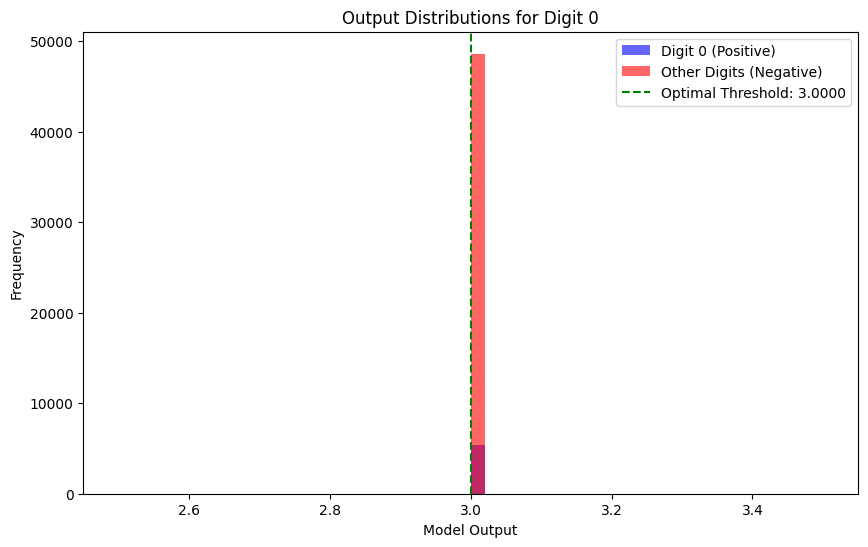

Accuracy for reduced model of digit 0: 0.9001
Precision: 0.0999, Recall: 1.0000, F1 Score: 0.1816
Processing digit 1


Optimal Threshold: 8.0
Maximum F1 Score: 0.24727251057209076


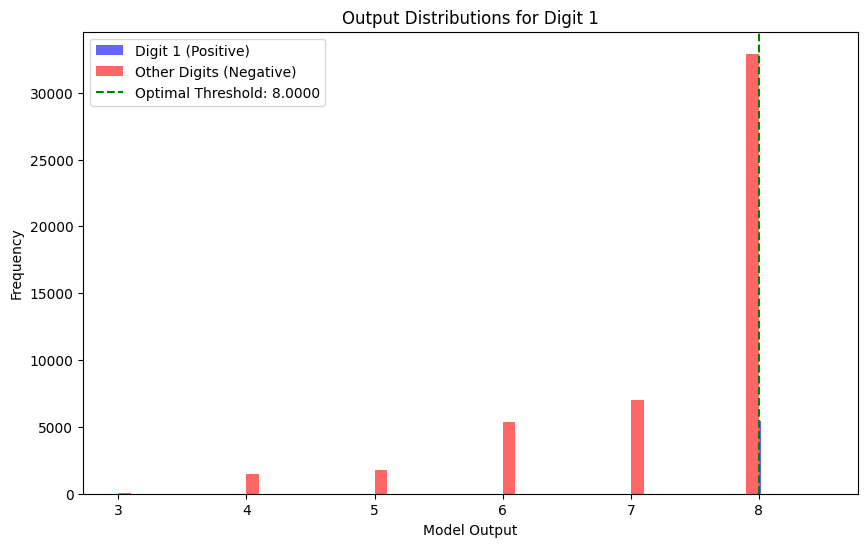

Accuracy for reduced model of digit 1: 0.8999
Precision: 0.1411, Recall: 1.0000, F1 Score: 0.2473
Processing digit 2


Optimal Threshold: 3.0
Maximum F1 Score: 0.18207502044619686


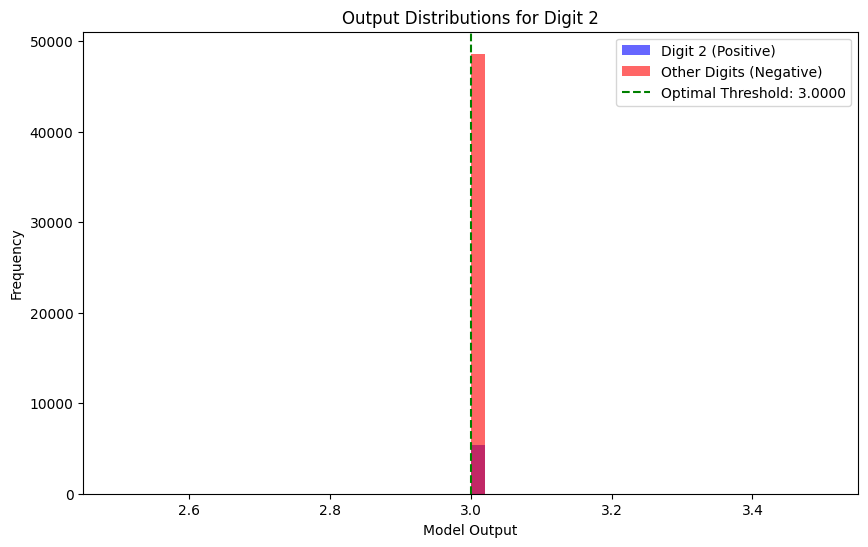

Accuracy for reduced model of digit 2: 0.8998
Precision: 0.1002, Recall: 1.0000, F1 Score: 0.1821
Processing digit 3


Optimal Threshold: 3.0
Maximum F1 Score: 0.18149359833759984


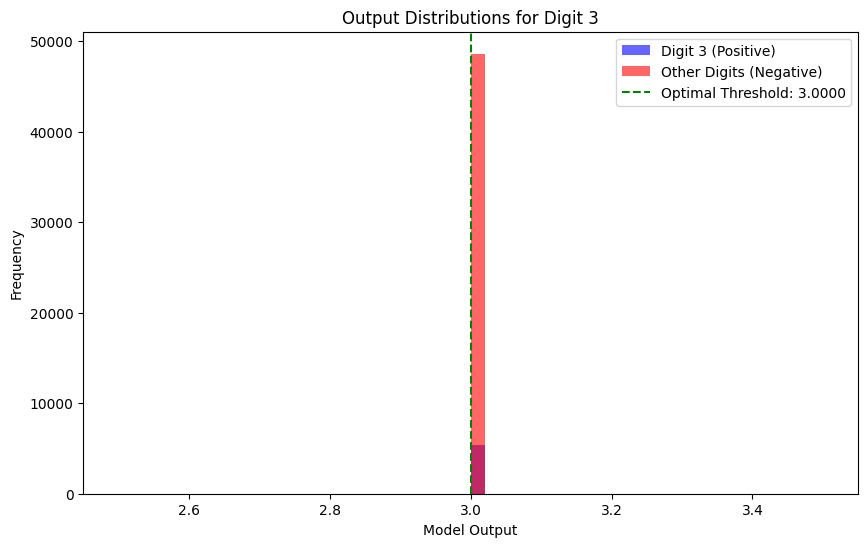

Accuracy for reduced model of digit 3: 0.9002
Precision: 0.0998, Recall: 1.0000, F1 Score: 0.1815
Processing digit 4


Optimal Threshold: 3.0
Maximum F1 Score: 0.18186085556142018


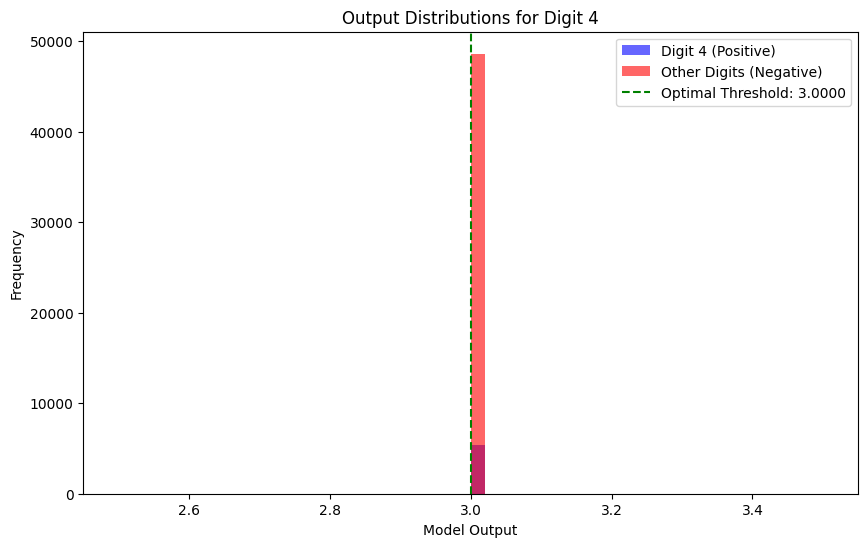

Accuracy for reduced model of digit 4: 0.9000
Precision: 0.1000, Recall: 1.0000, F1 Score: 0.1819
Processing digit 5


Optimal Threshold: 3.0
Maximum F1 Score: 0.18186085556142018


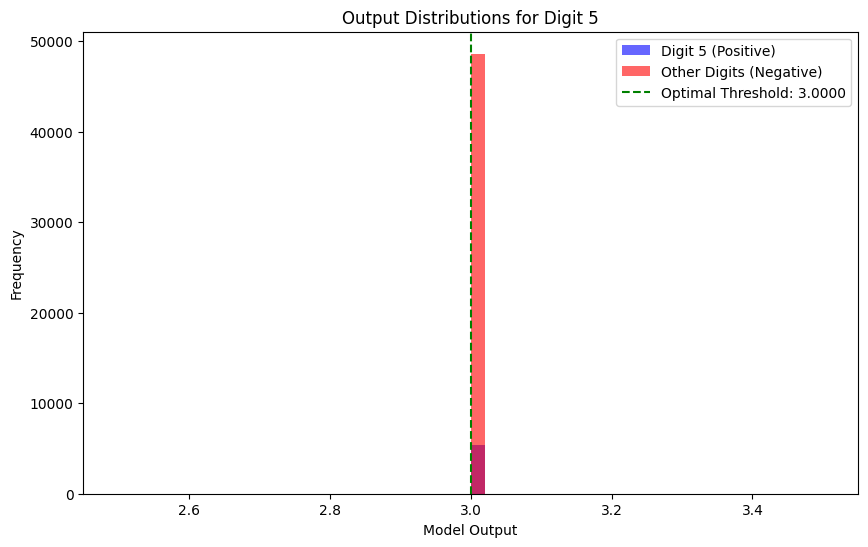

Accuracy for reduced model of digit 5: 0.9000
Precision: 0.1000, Recall: 1.0000, F1 Score: 0.1819
Processing digit 6


Optimal Threshold: 3.0
Maximum F1 Score: 0.18167724549377928


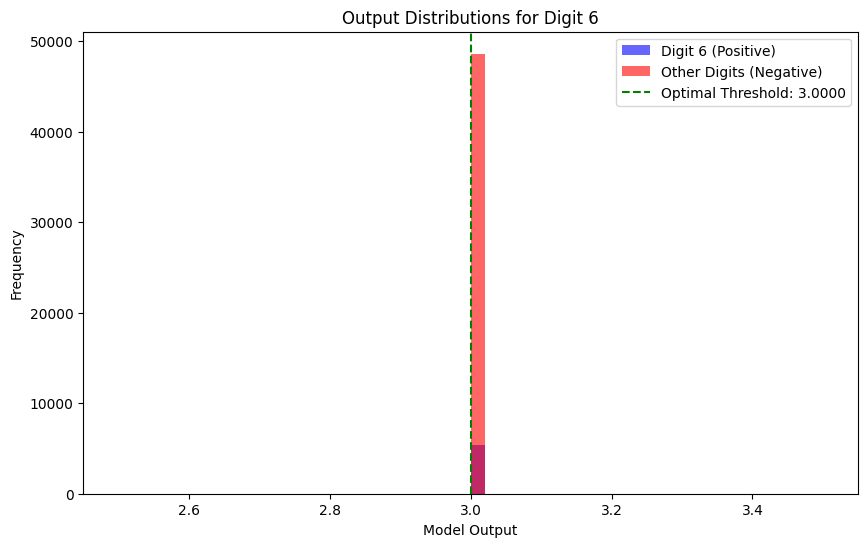

Accuracy for reduced model of digit 6: 0.9001
Precision: 0.0999, Recall: 1.0000, F1 Score: 0.1817
Processing digit 7


Optimal Threshold: 3.0
Maximum F1 Score: 0.18179965632579503


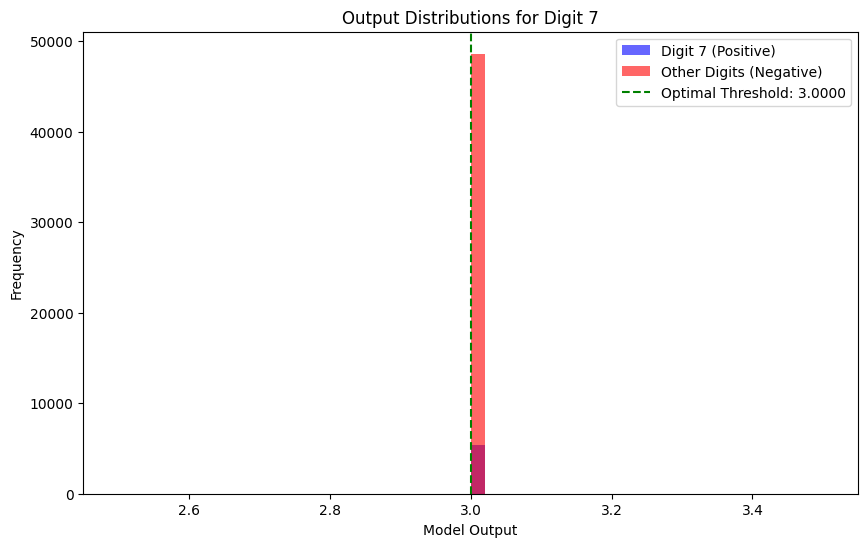

Accuracy for reduced model of digit 7: 0.9000
Precision: 0.1000, Recall: 1.0000, F1 Score: 0.1818
Processing digit 8


Optimal Threshold: 3.0
Maximum F1 Score: 0.18192205067734488


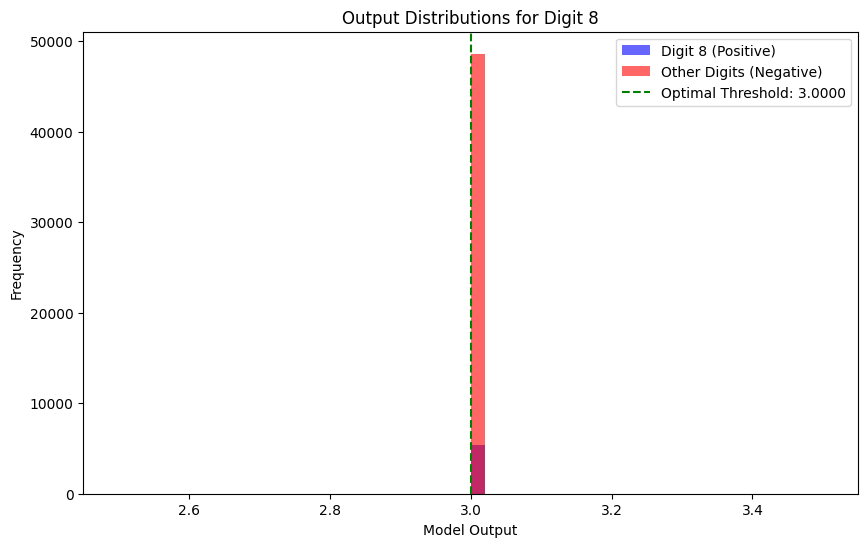

Accuracy for reduced model of digit 8: 0.8999
Precision: 0.1001, Recall: 1.0000, F1 Score: 0.1819
Processing digit 9


Optimal Threshold: 3.0
Maximum F1 Score: 0.1817690551629648


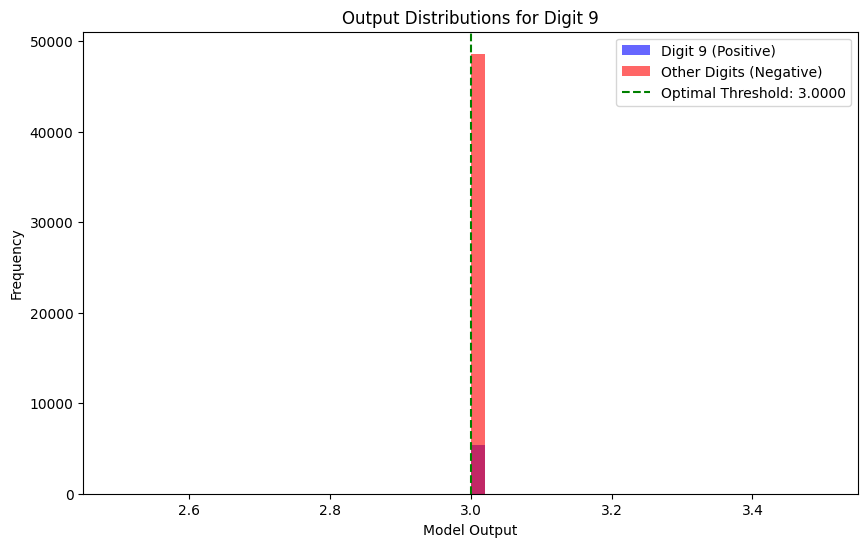

Accuracy for reduced model of digit 9: 0.9000
Precision: 0.1000, Recall: 1.0000, F1 Score: 0.1818


In [70]:
for digit in range(10):
    print(f"Processing digit {digit}")
    
    # All the necessary (used) connections for the current digit
    full_connections_for_digit = process_network_with_propagation(connections, unused_gates_per_digit, digit=digit)

    # All the logic gates (nodes) needed in the current digit
    logic_gates_per_layer = extract_logic_gates_per_layer(full_connections_for_digit, gate_name_to_index)

    # Combined list of gates and connections
    layer_specs = create_layer_specs(full_connections_for_digit, logic_gates_per_layer, input_size=400)

    # Create the custom model
    custom_model = CustomModel(layer_specs, digit=digit)

    # Move model to device
    if torch.cuda.is_available():
        custom_model = custom_model.to('cuda')

    # Store the model in the dictionary
    models_per_digit[digit] = custom_model
    
    # Evaluate the model to collect outputs and labels
    outputs, labels = custom_model.collect_outputs_and_labels(train_loader)  # Use a validation set

    # Find the optimal threshold
    optimal_threshold, precision, recall, f1_score = find_optimal_threshold(outputs, labels)

    # Plot the distributions and decision boundary
    plot_output_distributions(outputs, labels, optimal_threshold, digit)

    # Calculate accuracy using the optimal threshold
    accuracy = custom_model.calculate_accuracy(outputs, labels, optimal_threshold)
    print(f"Accuracy for reduced model of digit {digit}: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}")

    accuracies[digit] = accuracy


In [41]:
def find_optimal_threshold(outputs, labels):
    from sklearn.metrics import precision_recall_curve
    import numpy as np

    # Calculate precision and recall for various thresholds
    precision, recall, thresholds = precision_recall_curve(labels, outputs)

    # Avoid division by zero
    epsilon = 1e-6

    # Calculate F1 scores
    f1_scores = 2 * precision * recall / (precision + recall + epsilon)

    # Find the threshold that maximizes the F1 score
    max_f1_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[max_f1_idx]

    print(f"Optimal Threshold: {optimal_threshold}")
    print(f"Maximum F1 Score: {f1_scores[max_f1_idx]}")

    return optimal_threshold, precision[max_f1_idx], recall[max_f1_idx], f1_scores[max_f1_idx]


In [42]:
def plot_output_distributions(outputs, labels, optimal_threshold, digit):
    import matplotlib.pyplot as plt

    # Separate outputs by class
    positive_outputs = outputs[labels == 1]
    negative_outputs = outputs[labels == 0]

    plt.figure(figsize=(10, 6))
    plt.hist(positive_outputs.numpy(), bins=50, alpha=0.6, label=f"Digit {digit} (Positive)", color='blue')
    plt.hist(negative_outputs.numpy(), bins=50, alpha=0.6, label="Other Digits (Negative)", color='red')
    plt.axvline(optimal_threshold, color='green', linestyle='--', label=f"Optimal Threshold: {optimal_threshold:.4f}")
    plt.title(f"Output Distributions for Digit {digit}")
    plt.xlabel("Model Output")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


In [ ]:
for digit in range(10):
    print(f"Processing digit {digit}")

    # [Previous code to create the reduced model]

    # Evaluate the model to collect outputs and labels
    outputs, labels = custom_model.collect_outputs_and_labels(validation_loader)  # Use a validation set

    # Find the optimal threshold
    optimal_threshold, precision, recall, f1_score = find_optimal_threshold(outputs, labels)

    # Plot the distributions and decision boundary
    plot_output_distributions(outputs, labels, optimal_threshold, digit)

    # Calculate accuracy using the optimal threshold
    accuracy = custom_model.calculate_accuracy(outputs, labels, optimal_threshold)
    print(f"Accuracy for reduced model of digit {digit}: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}")

    accuracies[digit] = accuracy

##### UNUSED CODE BELOW

In [135]:
# returns the functions used to perform the calculations for each logic gate
# currently unused
def get_logic_gates_functions_for_layer(connections):
    logic_gates_per_layer = []
    
    # Map integer indices to the corresponding binary operation
    for layer_connections in connections:
        layer_gates = []
        for conn in layer_connections:
            layer_gates.append(lambda a, b, i=conn['gate']: bin_op(a, b, i))
        logic_gates_per_layer.append(layer_gates)
    
    return logic_gates_per_layer

# gets logic gates for the adjusted connections
logic_gates_functions_per_layer_digit_1 = get_logic_gates_functions_for_layer(full_connections_for_digit_1)
#logic_gates_functions_per_layer_digit_1

In [120]:
# Build the networks for all digits
custom_networks = {}
for digit in range(10):
    adjusted_connections = process_network_with_propagation(connections, unused_gates_per_digit, digit)
    logic_gates_per_layer = extract_logic_gates_per_layer(adjusted_connections)
    custom_networks[digit] = build_custom_network(adjusted_connections, logic_gates_per_layer)

# Test the network for a sample input

custom_networks[0](sample_input)

CustomLogicNetwork(
  (layers): ModuleList(
    (0): CustomLogicLayer(400, 2354, train)
    (1): CustomLogicLayer(2157, 1552, train)
  )
)

In [95]:
# OVERLOAD SUM FUNCTION, 
# FOR EACH SAMPLE FOR EACH MINI NET
# -> SUM THE SECOND LAYER OUTPUTS (1 or 0) SUM ALL ONES
# USE WHOLE DATASET (TRANSFORMED BASED ON PREV. CALCULATIONS 20x20, PARTITIONED, BINARIZED) 
# SAVE CSVs FOR EACH MININET

In [198]:
# connections: all connections for the overall difflogic model
# unused_gates_per_digit: gates that were used enough (based on thresholding term) to be considered used
# digit: from 0 - 9

custom_networks = {}
for digit in range(10):
    adjusted_connections = process_network_with_propagation(connections, unused_gates_per_digit, digit)
    logic_gates = get_logic_gates_for_layer(adjusted_connections)
    
    custom_networks[digit] = build_custom_network(adjusted_connections, logic_gates)
    # fix to that it also physically removes the input nodes only to use the necessary pixels

In [199]:
custom_networks

{0: CustomLogicNetwork(
   (layers): ModuleList(
     (0): CustomLogicLayer(400, 2354, train)
     (1): CustomLogicLayer(2499, 1552, train)
   )
 ),
 1: CustomLogicNetwork(
   (layers): ModuleList(
     (0): CustomLogicLayer(400, 2254, train)
     (1): CustomLogicLayer(2499, 1418, train)
   )
 ),
 2: CustomLogicNetwork(
   (layers): ModuleList(
     (0): CustomLogicLayer(400, 2371, train)
     (1): CustomLogicLayer(2500, 1585, train)
   )
 ),
 3: CustomLogicNetwork(
   (layers): ModuleList(
     (0): CustomLogicLayer(400, 2329, train)
     (1): CustomLogicLayer(2500, 1535, train)
   )
 ),
 4: CustomLogicNetwork(
   (layers): ModuleList(
     (0): CustomLogicLayer(400, 2323, train)
     (1): CustomLogicLayer(2499, 1515, train)
   )
 ),
 5: CustomLogicNetwork(
   (layers): ModuleList(
     (0): CustomLogicLayer(400, 2366, train)
     (1): CustomLogicLayer(2499, 1616, train)
   )
 ),
 6: CustomLogicNetwork(
   (layers): ModuleList(
     (0): CustomLogicLayer(400, 2327, train)
     (1): Cu

In [46]:
# Lists to store activation counts and gates per layer
activation_counts_per_layer = [] 
gates_per_layer = []  

# Hook function to track activations and record gates for each layer
def hook_fn_and_record_connections(module, input, output, layer_idx, debug=False):
    """
    Tracks activations and records connections for each neuron in the layer.

    Args:
    module (nn.Module): The layer being tracked.
    input (Tensor): The input to the layer (not used).
    output (Tensor): The output from the layer (activations).
    layer_idx (int): The index of the layer in the network.
    debug (boolean): Whether to print debug information.
    """
    # Initialize activation counts and gates for this layer if not already initialized
    if len(activation_counts_per_layer) <= layer_idx:
        activation_counts_per_layer.append(np.zeros(output.size(1)))
        gates_per_layer.append([])

    # Store activations (output > 0 means it fired)
    activations = (output > 0).cpu().numpy()

    # Update activation counts
    activation_counts_per_layer[layer_idx] += activations.sum(axis=0)

    # For each neuron in the layer, store its connections if it fires
    for neuron_idx, fired in enumerate(activations[0]):  # Assuming batch size of 1 for simplicity
        if fired:  # Only consider neurons that fire
            # Get the learned gate by taking the argmax of the weights for the neuron
            gate_op_idx = module.weights[neuron_idx].argmax().item()
            learned_gate = ALL_OPERATIONS[gate_op_idx]

            # Get the input connections (indices) for the gate
            input_neuron_a = module.indices[0][neuron_idx].item()
            input_neuron_b = module.indices[1][neuron_idx].item()

            # Record the gate and connections if the neuron fired
            gates_per_layer[layer_idx].append({
                'Gate': learned_gate,
                'Inputs': (input_neuron_a, input_neuron_b),
                'a': input_neuron_a,
                'b': input_neuron_b
            })

            if debug:
                print(f"Layer {layer_idx}, Neuron {neuron_idx} fired")
                print(f"Inputs: {input_neuron_a}, {input_neuron_b}")
                print(f"Gate: {learned_gate}")

In [ ]:
# TEST INFERENCE SPEED

import time

def measure_inference_time(model, data_loader):
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        for batch_inputs, _ in data_loader:
            batch_inputs = batch_inputs.to('cuda')
            outputs = model.diff_logic_model(batch_inputs)
    end_time = time.time()
    total_time = end_time - start_time
    return total_time

# Measure inference time on digit 4 images
digit4_inference_time = measure_inference_time(model, digit4_loader)
print(f"Inference time for digit 4 images: {digit4_inference_time:.4f} seconds")

# Measure inference time on all digits (optional)
all_digits_inference_time = measure_inference_time(model, test_loader)
print(f"Inference time for all digits: {all_digits_inference_time:.4f} seconds")
